# JCIE Revision - Six Selected Indonesian Stocks

This notebook preserves the original cell flow while revising the experiment for BBCA, BBRI, TLKM, ASII, ANTM, and INDF. The forecasting target is the next trading day's closing price, hyperparameter selection uses time-series cross-validation, a random-walk benchmark is included, and Diebold-Mariano tests are reported.


In [4]:
!pip install yfinance xgboost lightgbm seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 562.2 kB/s eta 0:00:001m577.3 kB/s eta 0:00:01


In [2]:
import yfinance as yf
import pandas as pd

# Six selected Indonesian stocks from different sectors
stock_tickers = {
    'BBCA': 'BBCA.JK',
    'BBRI': 'BBRI.JK',
    'TLKM': 'TLKM.JK',
    'ASII': 'ASII.JK',
    'ANTM': 'ANTM.JK',
    'INDF': 'INDF.JK'
}

start_date = '2020-01-01'
# yfinance treats end as exclusive, so 2026-03-06 includes 2026-03-05
end_date = '2026-03-06'

raw_data = {}

for stock_name, ticker in stock_tickers.items():
    print('=' * 80)
    print(f'Downloading stock data for: {stock_name} ({ticker})')
    print('=' * 80)

    df_download = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )

    if isinstance(df_download.columns, pd.MultiIndex):
        df_download.columns = df_download.columns.droplevel(1)
        df_download.columns.name = None

    df_download = df_download.reset_index()
    df_download['Date'] = pd.to_datetime(df_download['Date'])
    df_download = df_download.sort_values('Date').reset_index(drop=True)

    raw_data[stock_name] = df_download.copy()

    print('Data shape:', df_download.shape)
    print('First few rows:')
    print(df_download.head())

    filename = f'{stock_name}_raw.csv'
    df_download.to_csv(filename, index=False)
    print(f'Data saved to {filename}\n')

print('Downloaded stocks:', ', '.join(raw_data.keys()))


Data shape: (1489, 6)
First few rows:
        Date        Close         High          Low         Open    Volume
0 2020-01-02  5518.781250  5593.024944  5510.531951  5522.905900  49445000
1 2020-01-03  5609.523926  5609.523926  5547.654177  5568.277426  47755500
2 2020-01-06  5555.902832  5568.276780  5518.780987  5543.528884  27300000
3 2020-01-07  5560.027832  5584.775730  5551.778533  5555.903182  45022500
4 2020-01-08  5510.531738  5564.152182  5502.282439  5502.282439  53692500
Data saved to BBCA_raw.csv

Data shape: (1489, 6)
First few rows:
        Date        Close         High          Low         Open     Volume
0 2020-01-02  2680.163818  2680.163818  2649.776409  2674.086304   45886302
1 2020-01-03  2686.240967  2698.395995  2668.008588  2686.240967   91189705
2 2020-01-06  2655.854004  2668.008870  2625.466594  2649.776489   48648450
3 2020-01-07  2674.086426  2680.163941  2661.931559  2680.163941  114344885
4 2020-01-08  2661.931396  2674.086262  2637.621502  2661.931396  

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import time
import json
import warnings

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from scipy import stats

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

print('=' * 80)
print('PROGRAM PREDIKSI HARGA SAHAM - JCIE REVISION')
print('Stocks: BBCA, BBRI, TLKM, ASII, ANTM, INDF')
print('Models: Random Walk, Linear Regression, XGBoost, LightGBM')
print('Target: Close(t+1) using information available through day t')
print('=' * 80)


PROGRAM PREDIKSI HARGA SAHAM - JCIE REVISION
Stocks: BBCA, BBRI, TLKM, ASII, ANTM, INDF
Models: Random Walk, Linear Regression, XGBoost, LightGBM
Target: Close(t+1) using information available through day t


## Preprocessing



[2] DATA PREPROCESSING...

PREPROCESSING BBCA (BBCA.JK)

Statistik Deskriptif Data Awal:
              Open          High          Low         Close        Volume
count  1489.000000   1489.000000  1489.000000   1489.000000  1.489000e+03
mean   7114.279634   7180.764172  7046.937690   7111.700660  9.831114e+07
std    1444.282422   1448.651905  1442.989477   1446.149291  7.910957e+07
min    3670.938799   4028.115327  3567.822165   3654.439697  0.000000e+00
25%    5706.947712   5753.886683  5634.271834   5669.070312  5.998390e+07
50%    7332.492676   7434.404245  7282.238330   7371.424316  8.082900e+07
75%    8177.303074   8224.709352  8106.196777   8169.086914  1.121112e+08
max    9975.975656  10021.738281  9861.573421  10021.738281  1.432993e+09

Membuat indikator teknikal...
Baris dengan NaN dihapus: 30 baris
Data tersisa: 1459 baris

Outlier diagnostic (IQR, observations retained):
  Lower bound : 2101.3584
  Upper bound : 11834.1064
  Detected    : 0 observations

Correlation with n

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


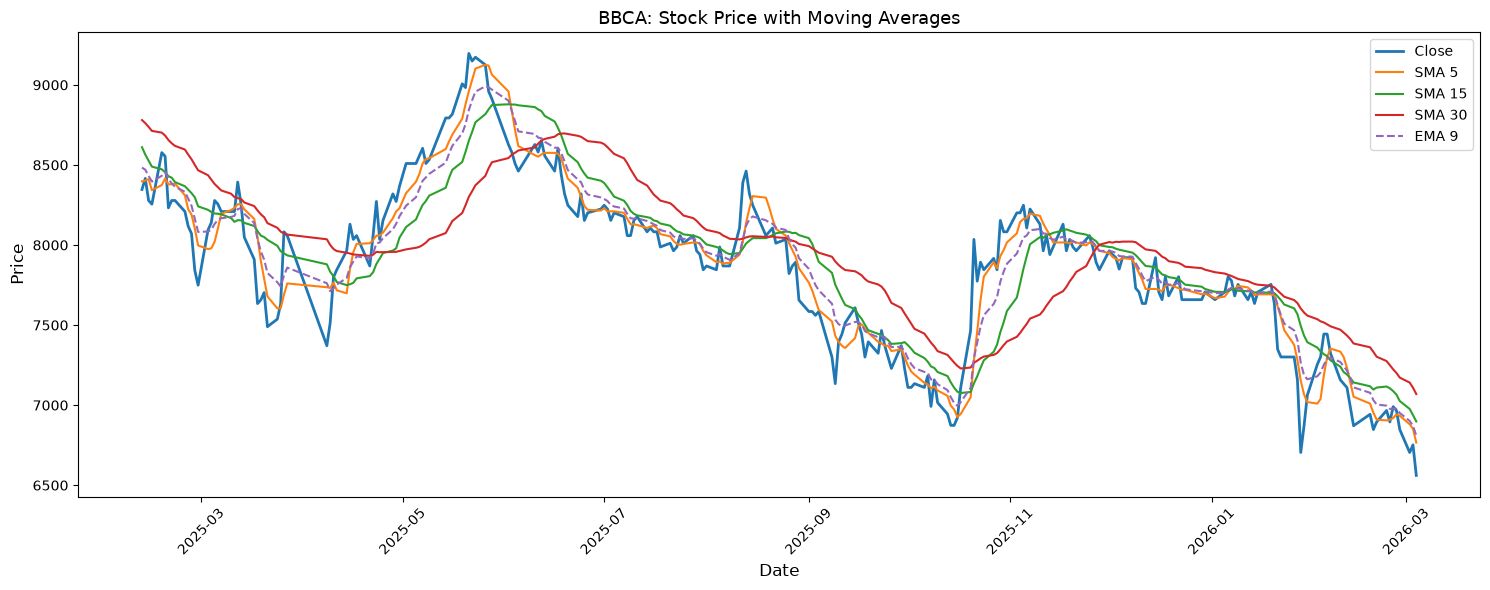

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


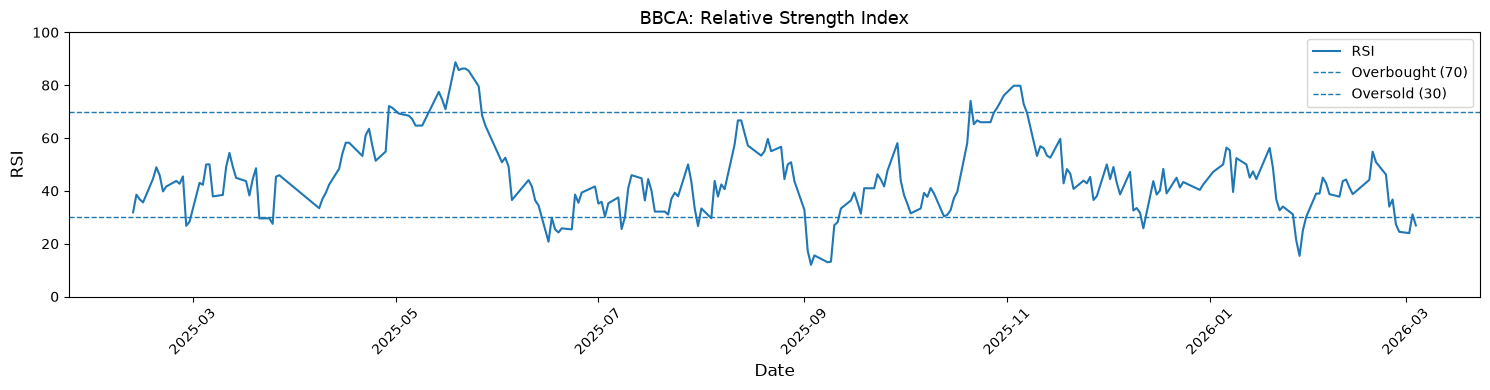

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


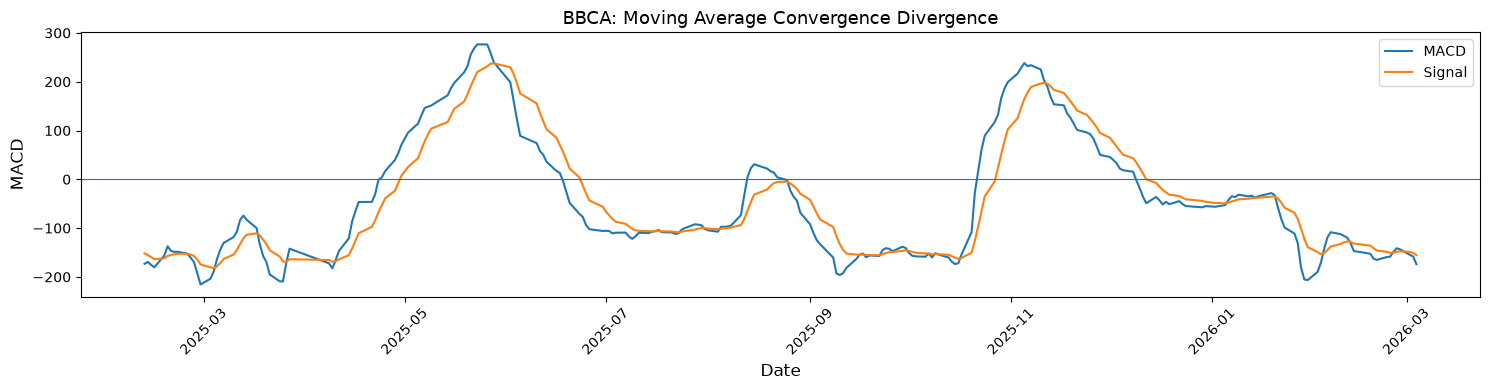

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


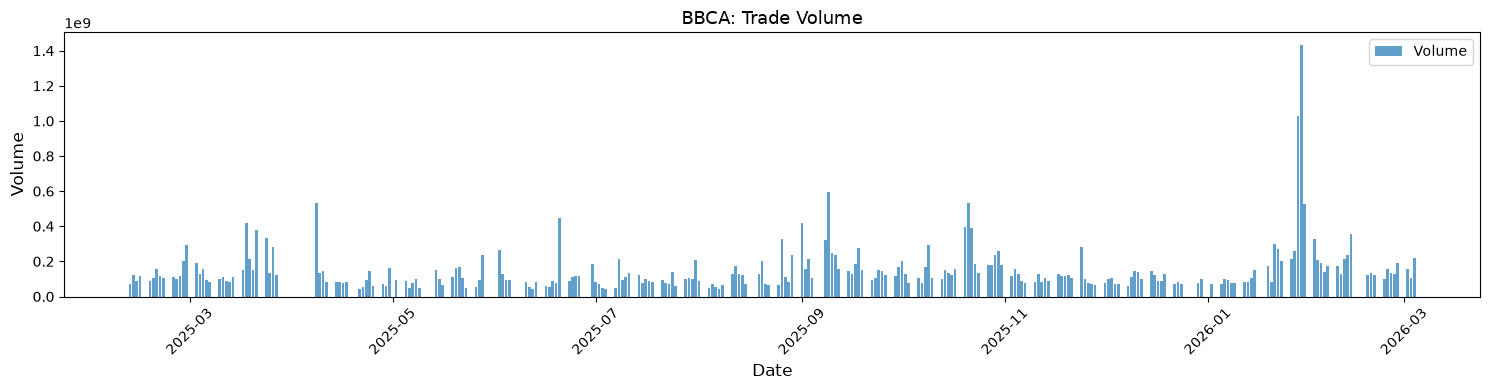

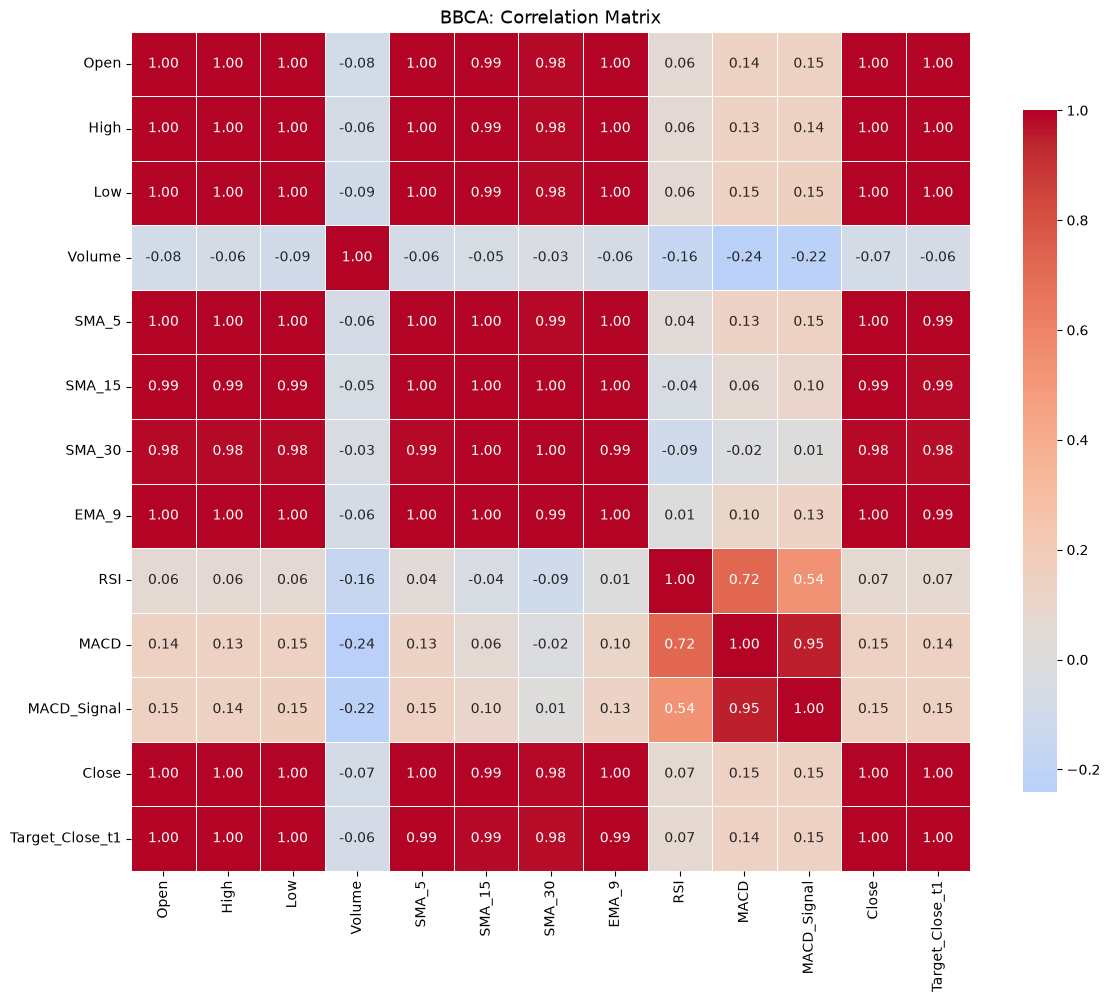

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



PREPROCESSING BBRI (BBRI.JK)

Statistik Deskriptif Data Awal:
              Open         High          Low        Close        Volume
count  1489.000000  1489.000000  1489.000000  1489.000000  1.489000e+03
mean   3327.575070  3364.467977  3287.598491  3323.546897  1.940185e+08
std     735.880898   739.033931   735.838772   738.263281  1.198497e+08
min    1420.773451  1433.402872  1363.942727  1370.257324  2.767650e+07
25%    2844.255818  2860.491072  2791.030460  2826.023193  1.120705e+08
50%    3394.510421  3430.718830  3350.222656  3387.200684  1.618153e+08
75%    3800.792405  3829.007963  3742.828250  3783.747803  2.344031e+08
max    5216.774555  5237.476041  5154.670096  5216.774414  1.000598e+09

Membuat indikator teknikal...
Baris dengan NaN dihapus: 30 baris
Data tersisa: 1459 baris

Outlier diagnostic (IQR, observations retained):
  Lower bound : 1551.5275
  Upper bound : 5153.7653
  Detected    : 8 observations

Correlation with next-day Close target:
Close          0.996261


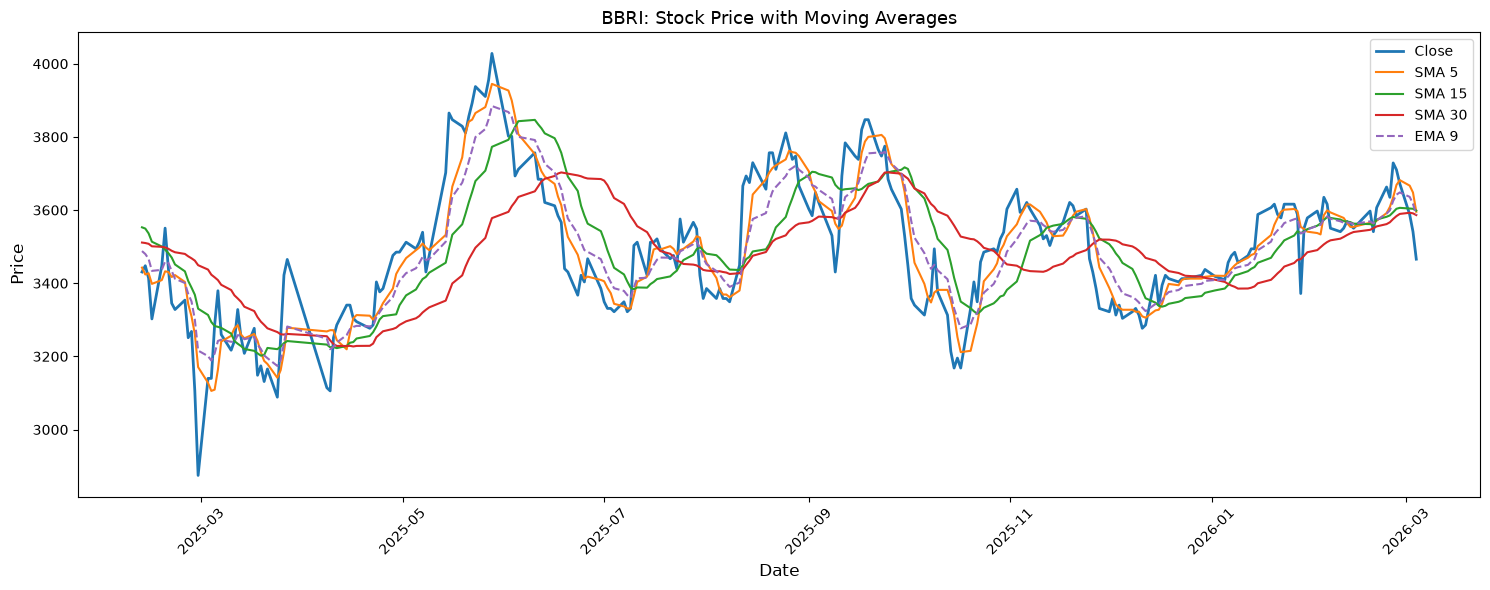

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


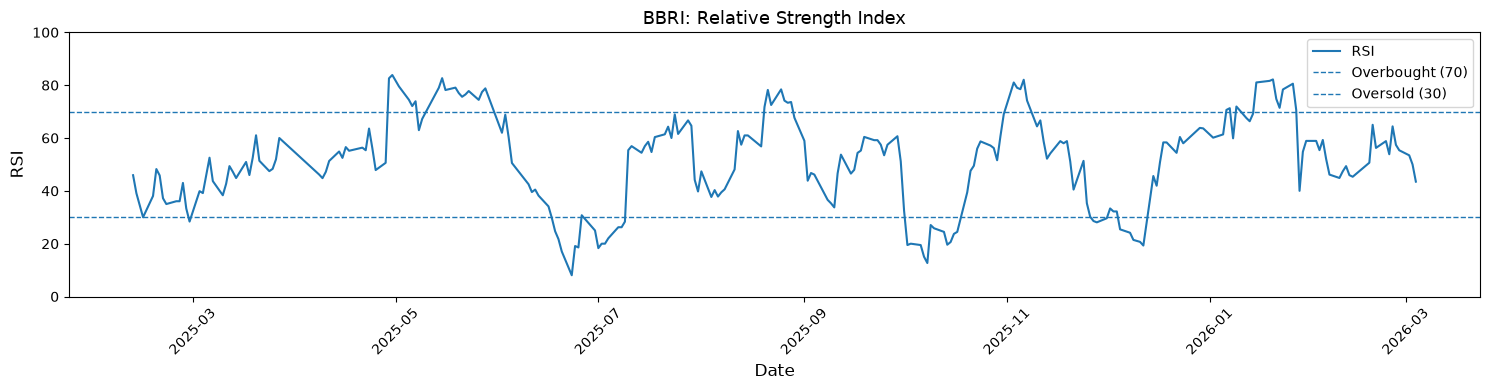

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


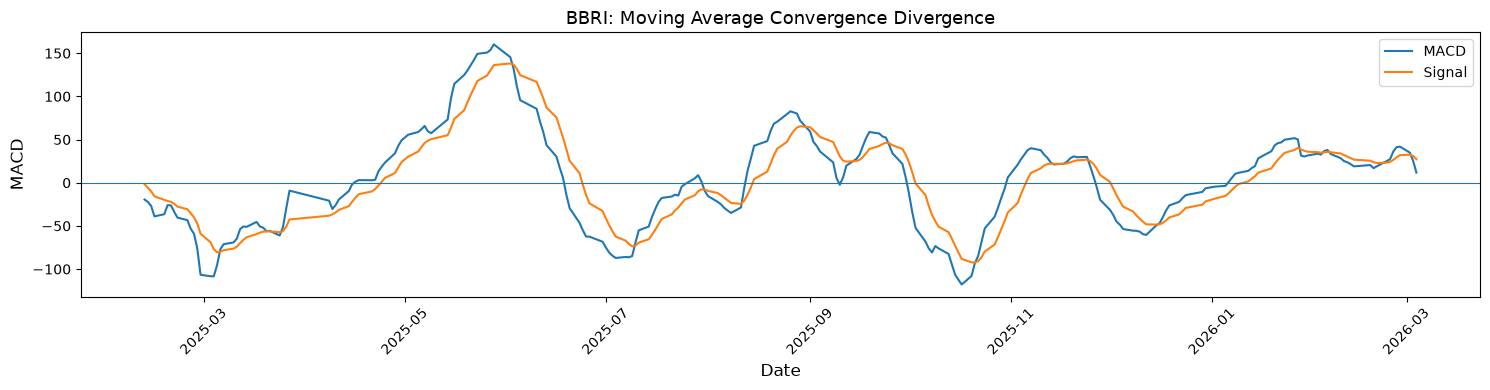

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


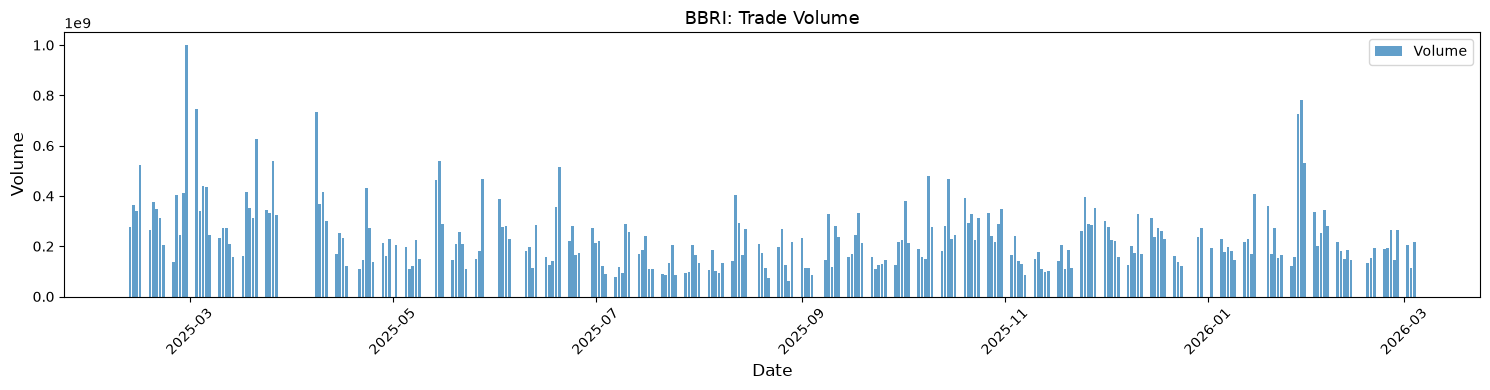

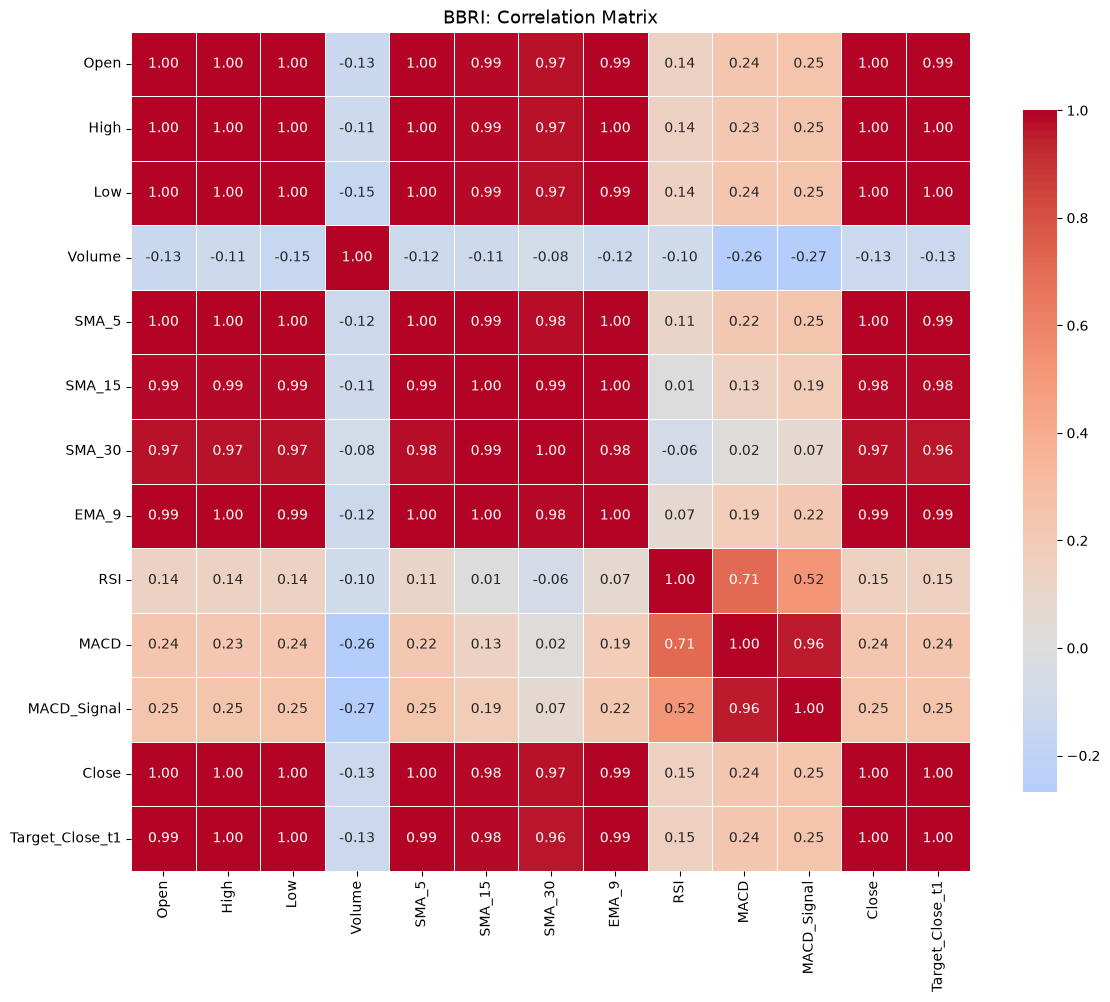

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



PREPROCESSING TLKM (TLKM.JK)

Statistik Deskriptif Data Awal:
              Open         High          Low        Close        Volume
count  1489.000000  1489.000000  1489.000000  1489.000000  1.489000e+03
mean   2755.923330  2787.639905  2719.971950  2752.858748  1.155430e+08
std     442.992203   443.060336   441.066148   443.476897  7.685350e+07
min    1727.339062  1843.763186  1659.599978  1774.756226  0.000000e+00
25%    2382.733278  2420.384189  2350.535630  2382.733398  6.872550e+07
50%    2746.332504  2783.064388  2718.341960  2755.326416  9.659490e+07
75%    3150.204834  3182.514648  3123.749125  3147.002930  1.375526e+08
max    3643.082520  3697.341101  3604.326323  3681.838623  1.155861e+09

Membuat indikator teknikal...
Baris dengan NaN dihapus: 30 baris
Data tersisa: 1459 baris

Outlier diagnostic (IQR, observations retained):
  Lower bound : 1204.6600
  Upper bound : 4323.3329
  Detected    : 0 observations

Correlation with next-day Close target:
Close          0.992836


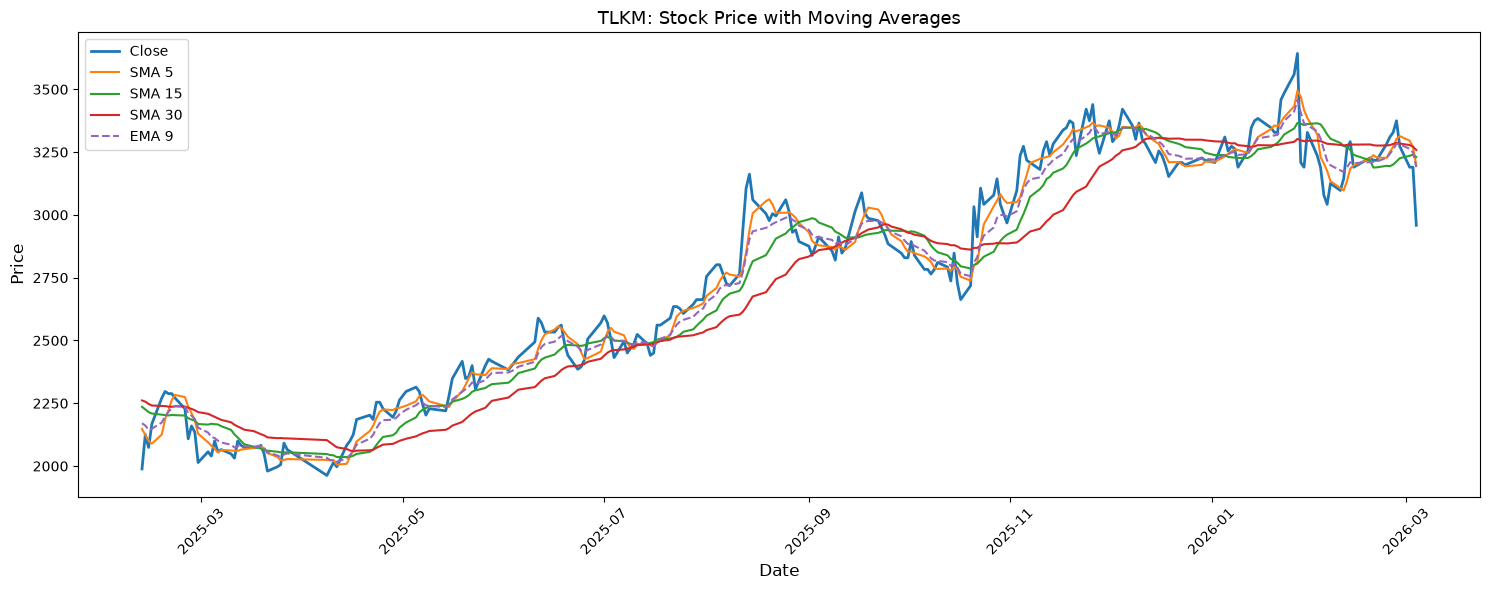

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


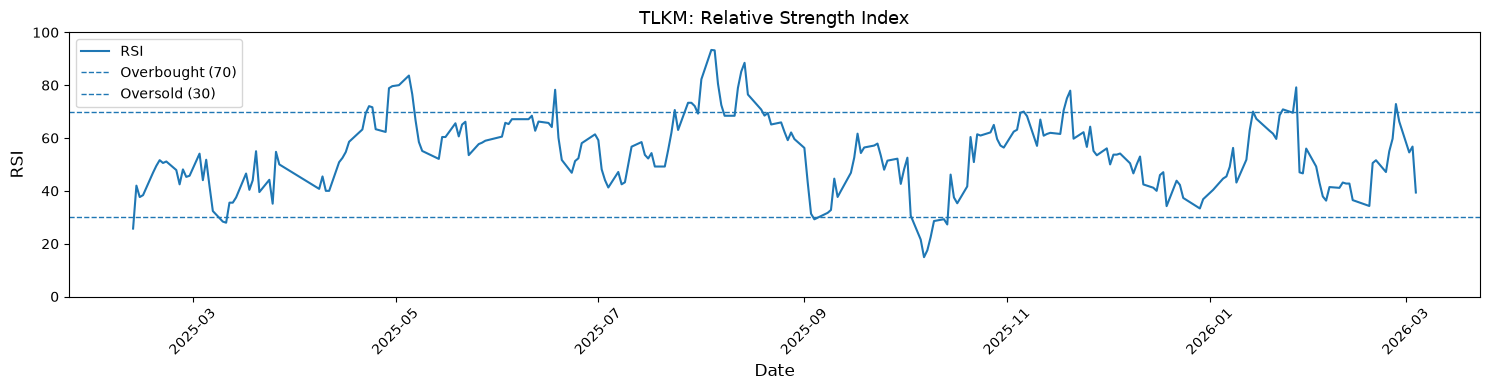

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


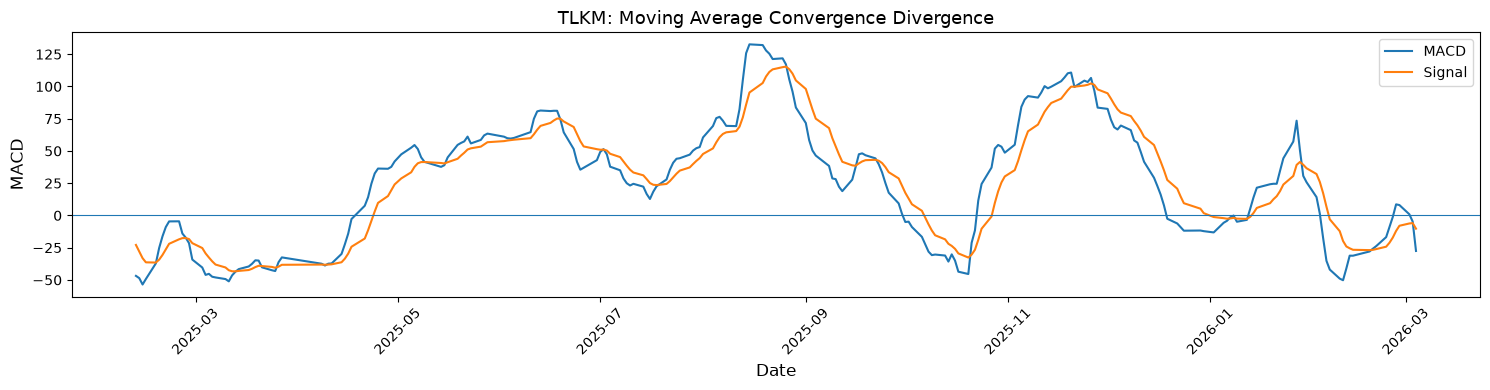

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


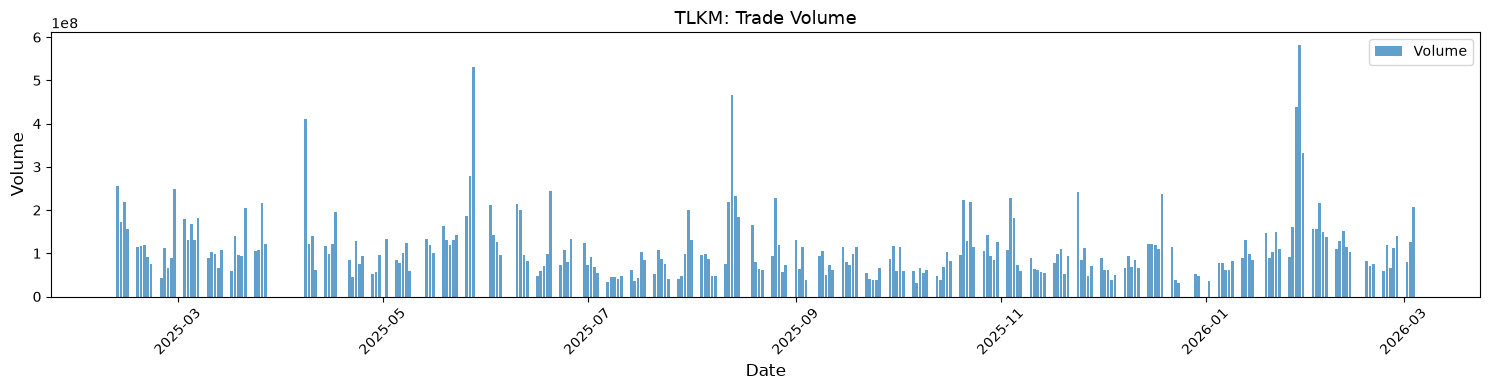

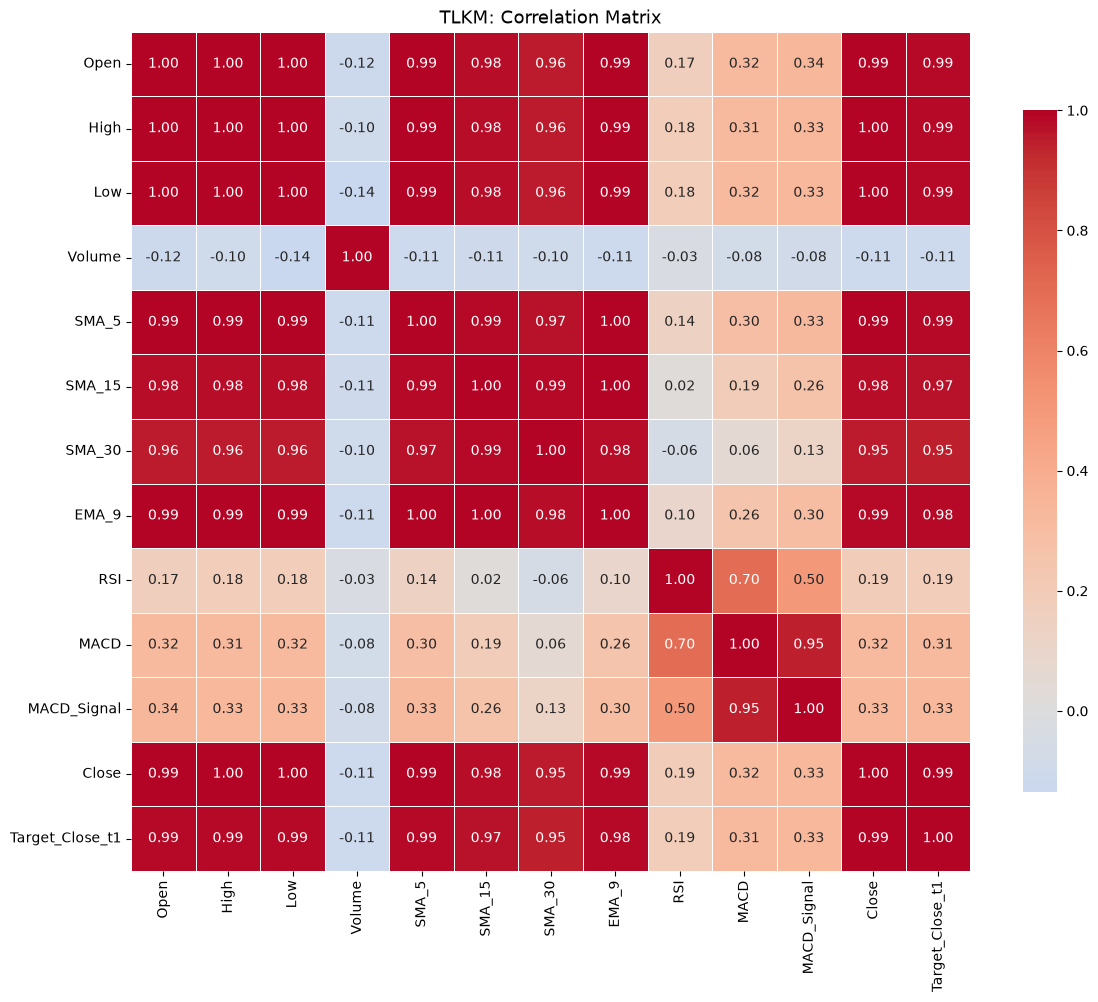

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



PREPROCESSING ASII (ASII.JK)

Statistik Deskriptif Data Awal:
              Open         High          Low        Close        Volume
count  1489.000000  1489.000000  1489.000000  1489.000000  1.489000e+03
mean   4282.442574  4332.608304  4221.906075  4276.556031  4.987419e+07
std     791.362383   798.216904   782.509462   794.124966  3.195146e+07
min    2068.201636  2318.698587  2068.201636  2106.739990  0.000000e+00
25%    3835.358427  3894.053278  3782.303746  3825.542725  3.013720e+07
50%    4228.500623  4264.034810  4175.200752  4217.429688  4.155260e+07
75%    4644.706986  4690.412591  4583.837262  4637.137695  5.821110e+07
max    6996.715861  7115.708052  6877.724094  7044.312988  3.114024e+08

Membuat indikator teknikal...
Baris dengan NaN dihapus: 30 baris
Data tersisa: 1459 baris

Outlier diagnostic (IQR, observations retained):
  Lower bound : 2579.6459
  Upper bound : 5883.7445
  Detected    : 122 observations

Correlation with next-day Close target:
Close          0.99420

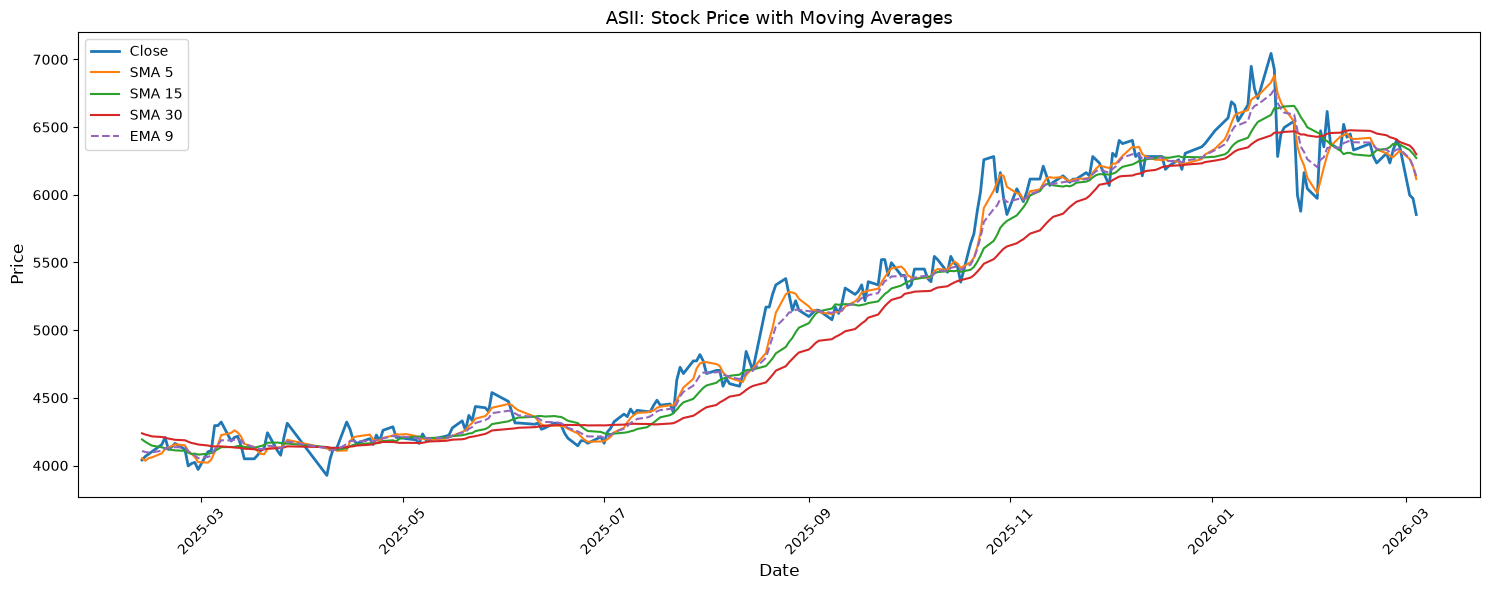

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


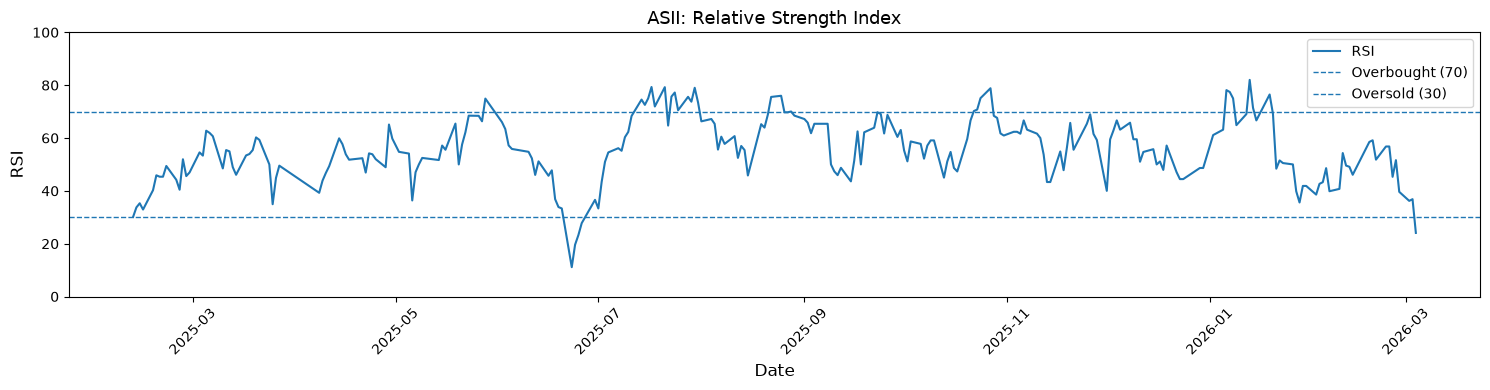

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


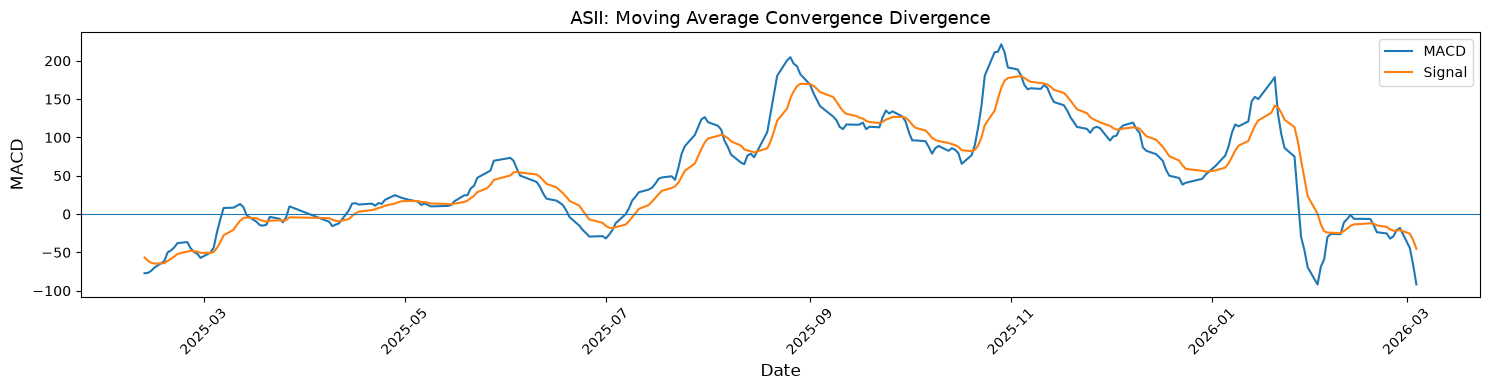

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


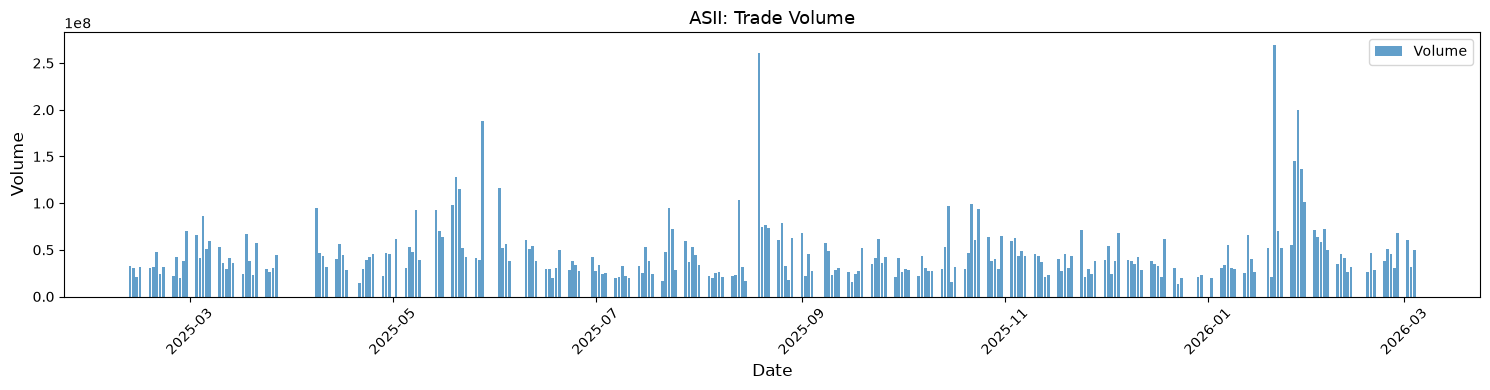

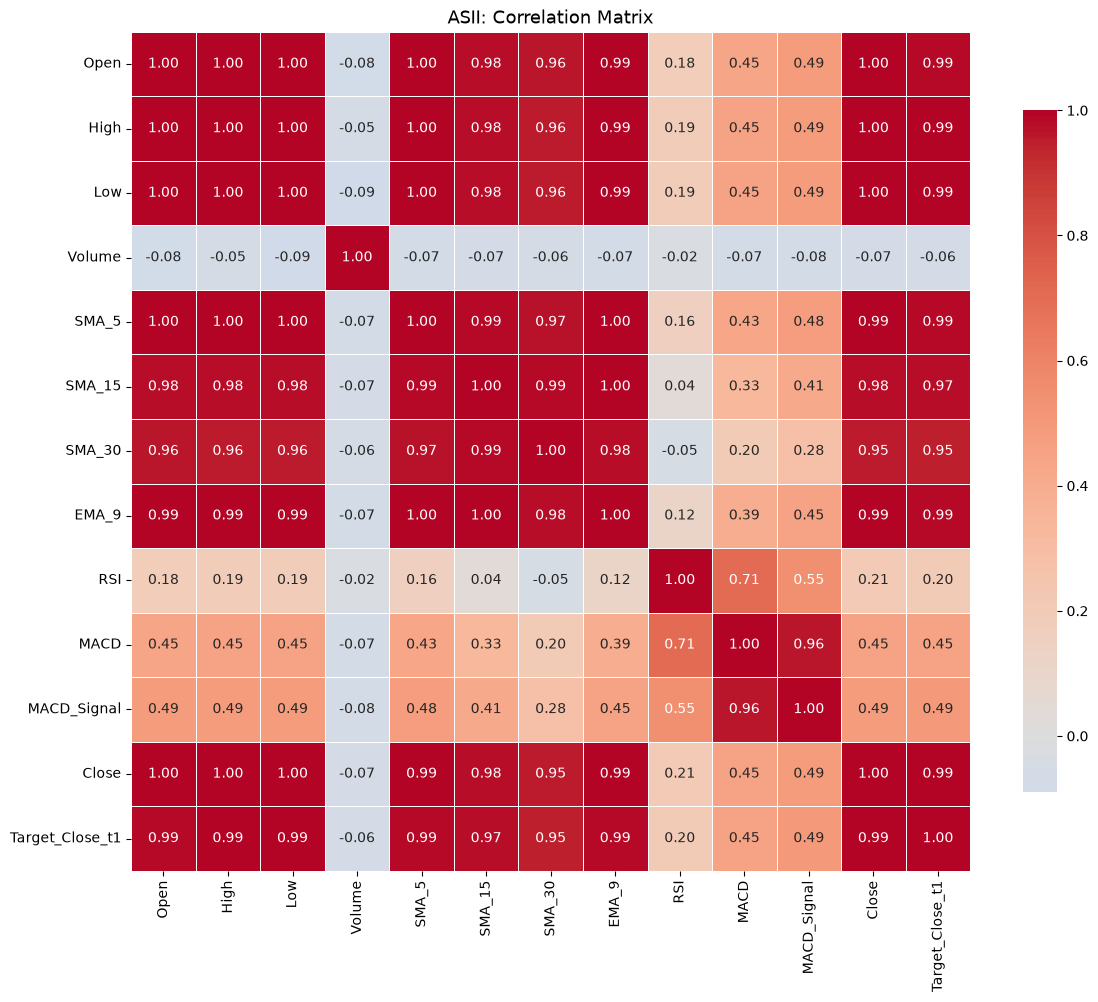

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



PREPROCESSING ANTM (ANTM.JK)

Statistik Deskriptif Data Awal:
              Open         High          Low        Close        Volume
count  1489.000000  1489.000000  1489.000000  1489.000000  1.489000e+03
mean   1627.502119  1658.001320  1595.999259  1624.062335  1.442888e+08
std     731.948346   749.860446   712.575115   730.208792  2.063822e+08
min     266.295850   278.539316   258.643681   266.295837  8.977100e+06
25%    1295.934805  1318.125320  1269.354112  1291.496582  4.615760e+07
50%    1555.982300  1573.093225  1529.833136  1553.429443  8.330320e+07
75%    1850.718826  1881.693059  1819.744139  1850.718628  1.516773e+08
max    4435.472008  4631.154764  4239.789419  4435.472168  2.186653e+09

Membuat indikator teknikal...
Baris dengan NaN dihapus: 30 baris
Data tersisa: 1459 baris

Outlier diagnostic (IQR, observations retained):
  Lower bound : 485.4294
  Upper bound : 2682.2820
  Detected    : 268 observations

Correlation with next-day Close target:
Close          0.996569

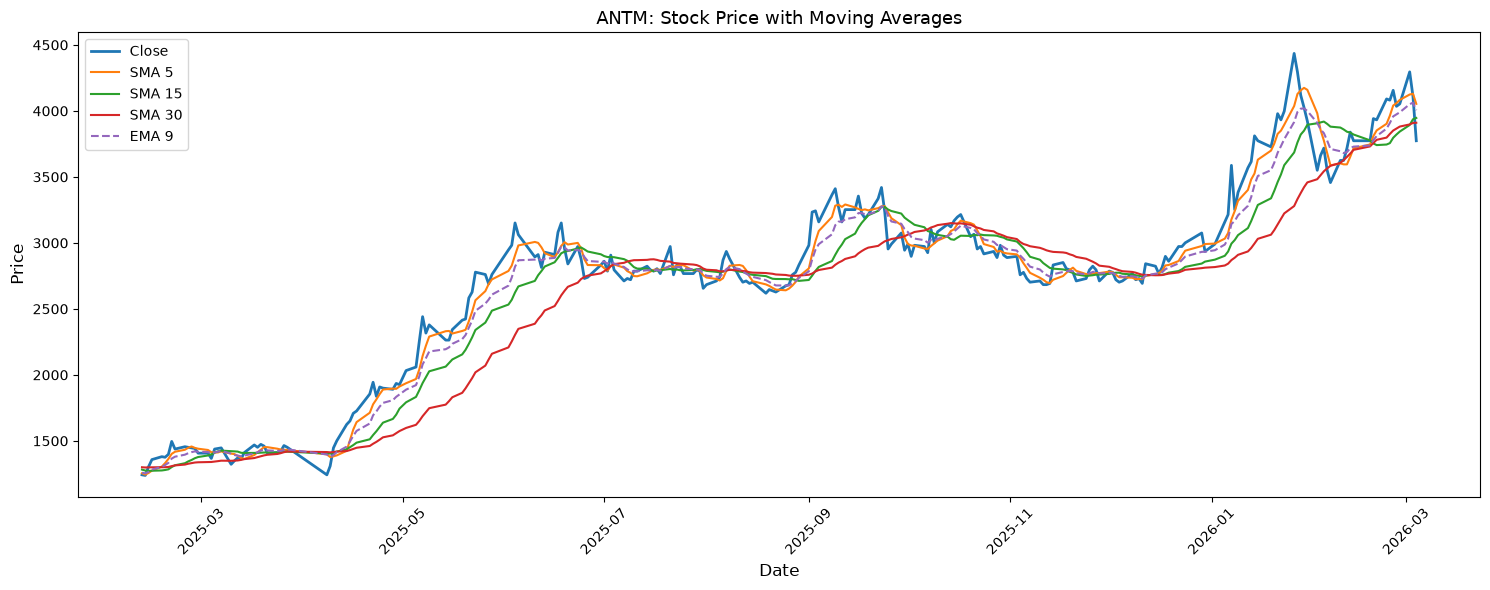

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


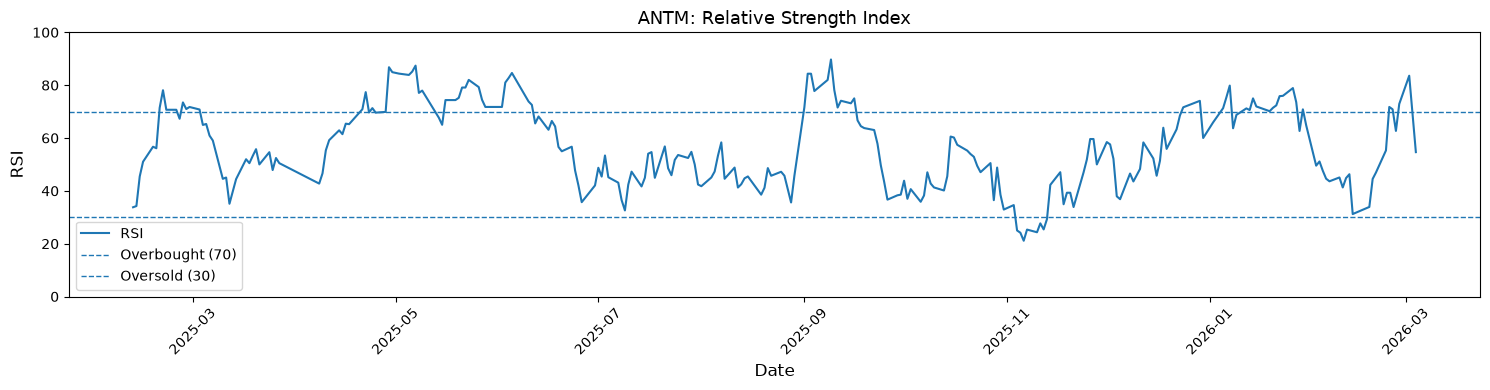

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


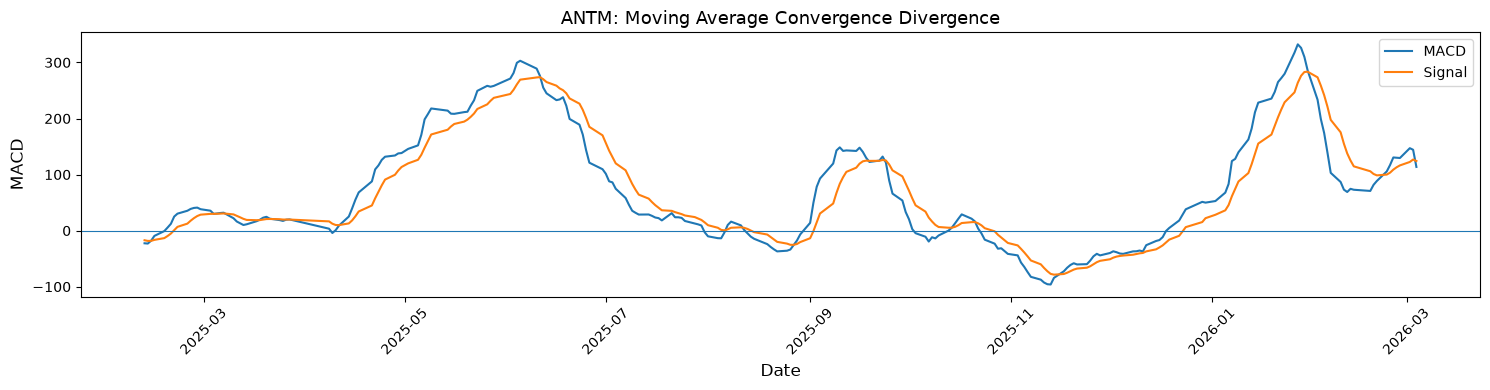

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


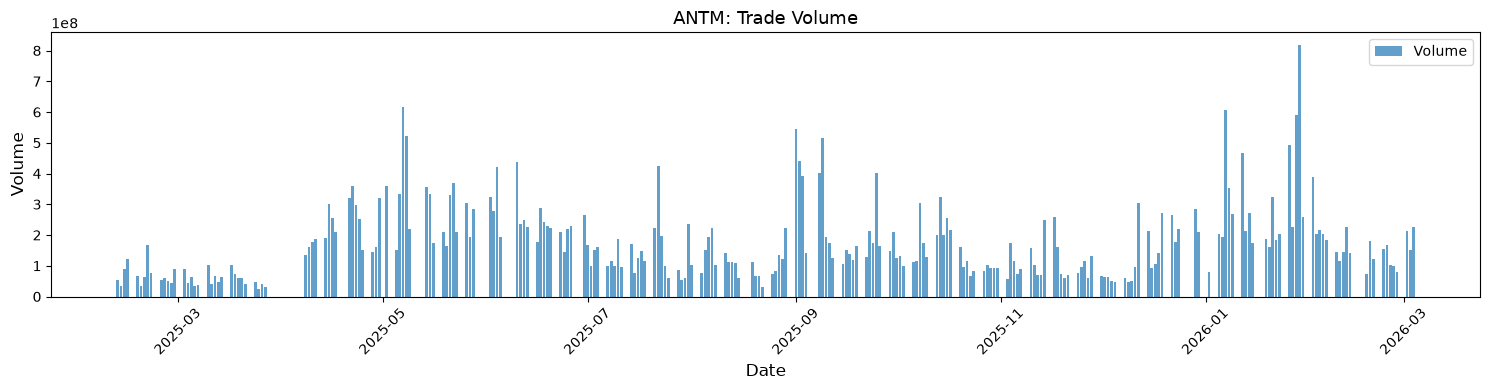

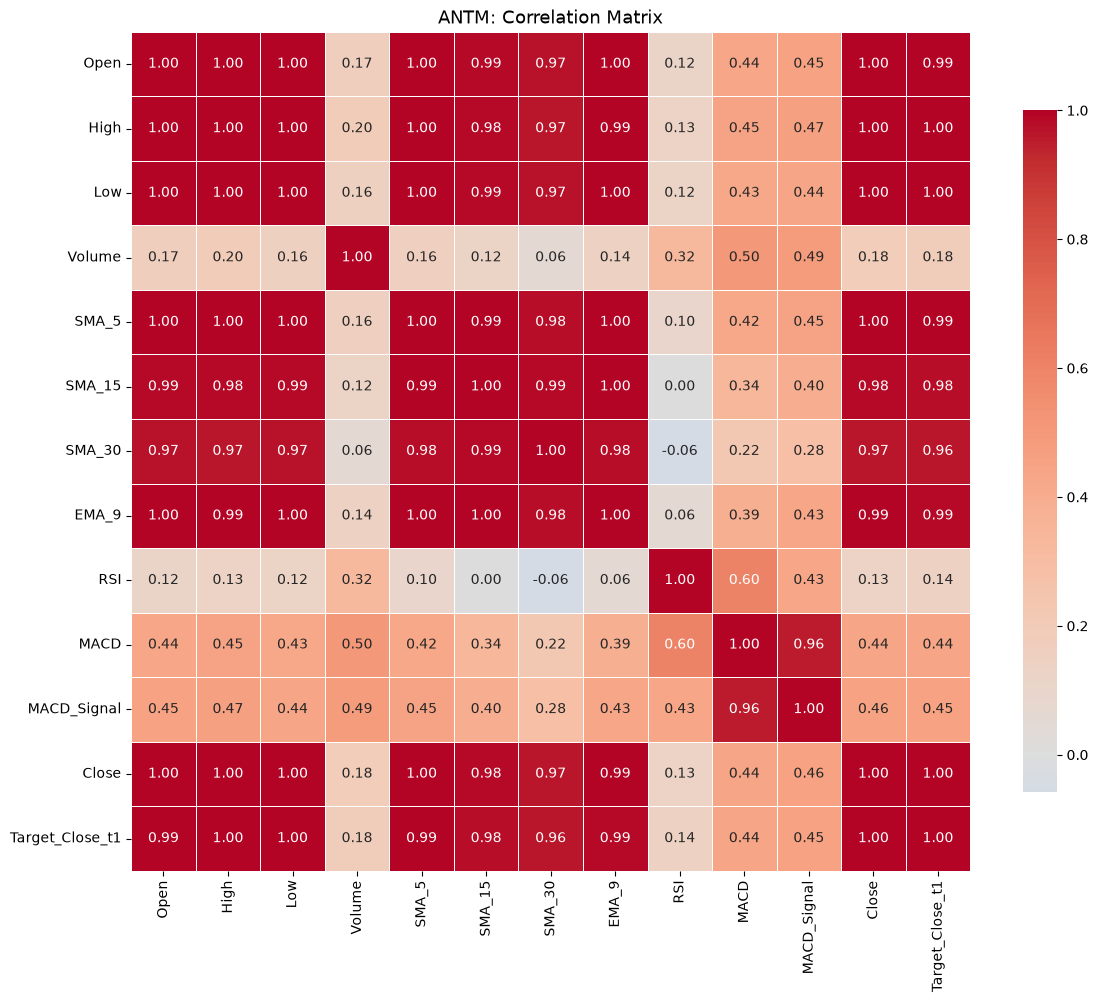

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



PREPROCESSING INDF (INDF.JK)

Statistik Deskriptif Data Awal:
              Open         High          Low        Close        Volume
count  1489.000000  1489.000000  1489.000000  1489.000000  1.489000e+03
mean   5836.635473  5898.684497  5767.529884  5831.792042  9.771197e+06
std     789.257657   796.193107   781.686186   791.279151  9.410583e+06
min    4027.179859  4215.365834  3763.719495  3801.356689  1.566700e+06
25%    5250.736056  5300.194824  5201.969158  5250.735840  5.859900e+06
50%    5644.513766  5688.784668  5599.398258  5644.513672  8.110900e+06
75%    6322.608887  6390.153979  6261.922669  6322.608887  1.168560e+07
max    8310.398898  8454.094437  8094.855411  8166.703125  2.902043e+08

Membuat indikator teknikal...
Baris dengan NaN dihapus: 30 baris
Data tersisa: 1459 baris

Outlier diagnostic (IQR, observations retained):
  Lower bound : 3581.9592
  Upper bound : 8006.6799
  Detected    : 6 observations

Correlation with next-day Close target:
Close          0.992177


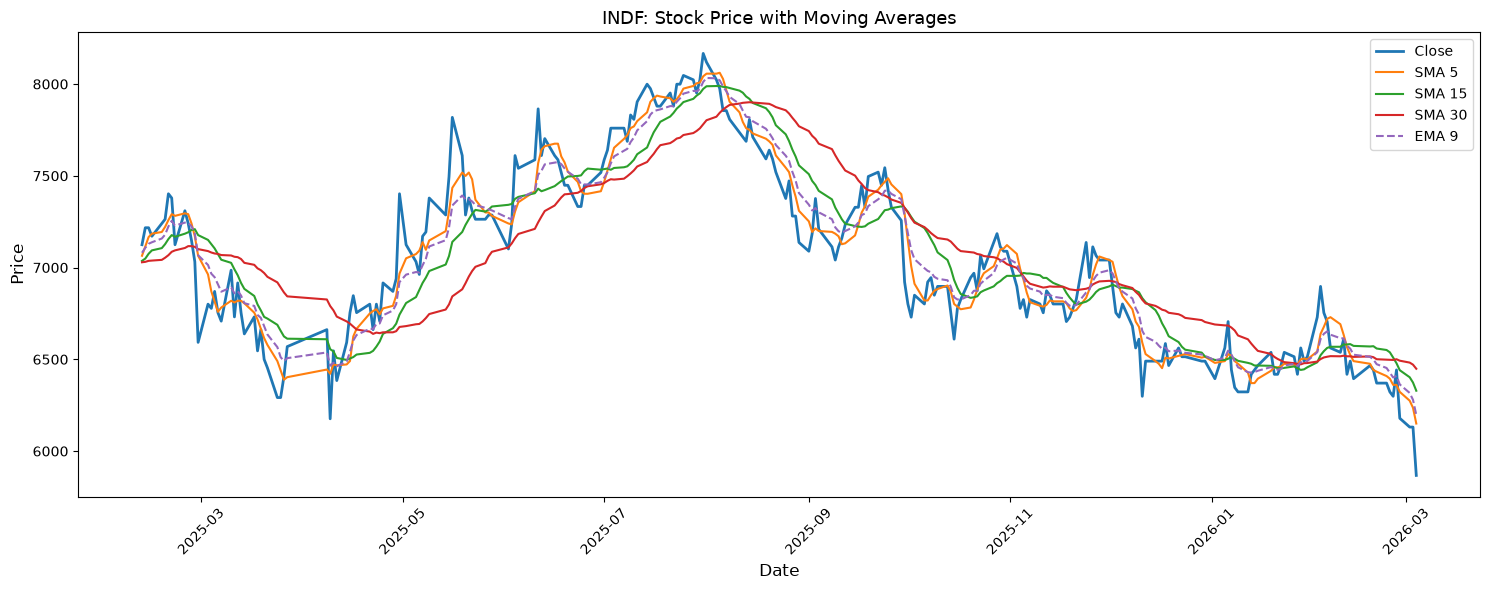

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


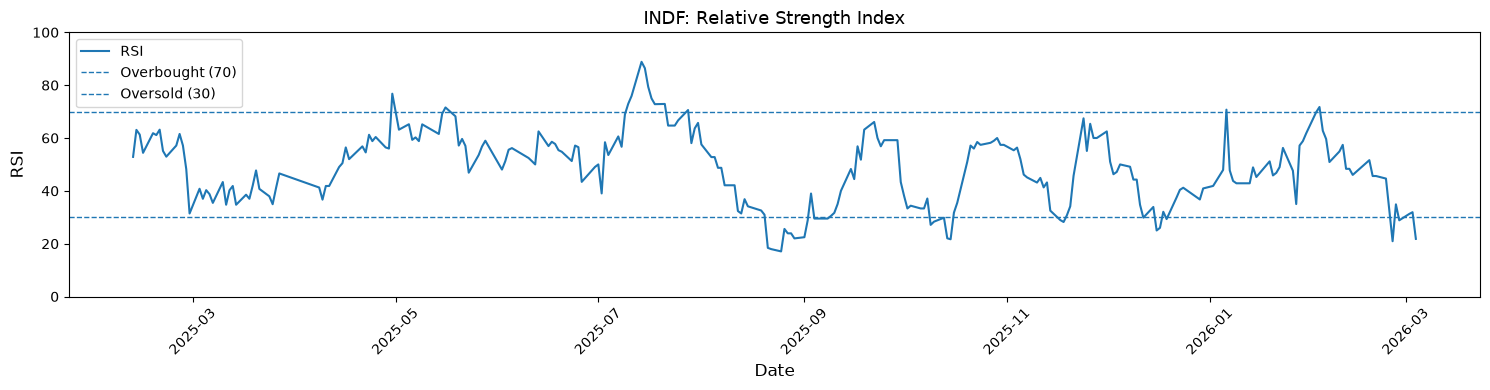

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


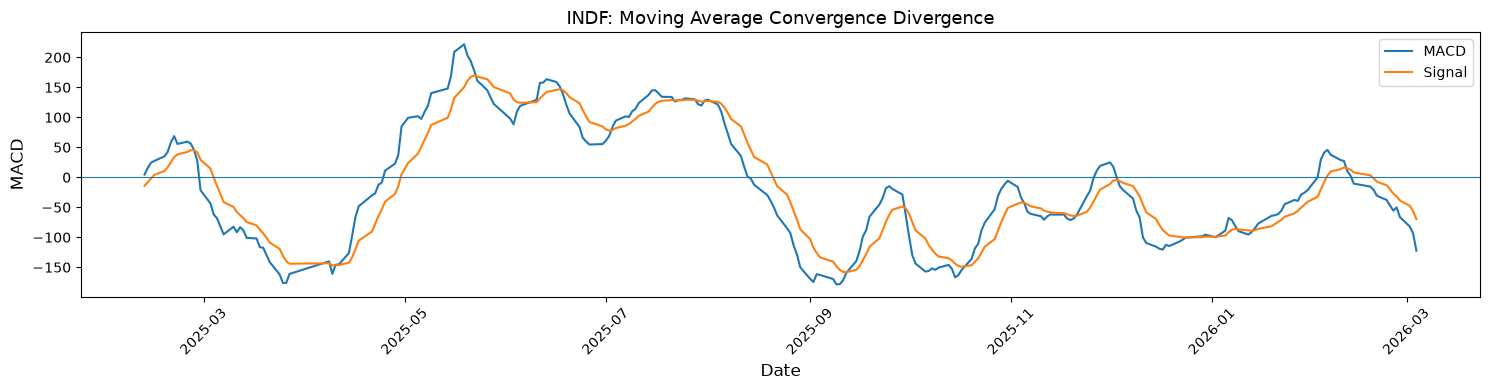

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


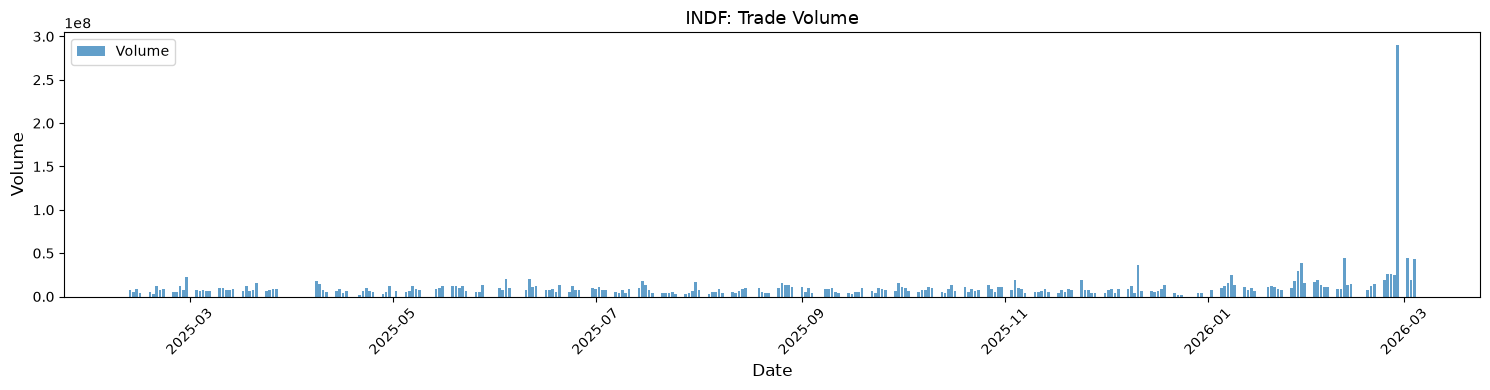

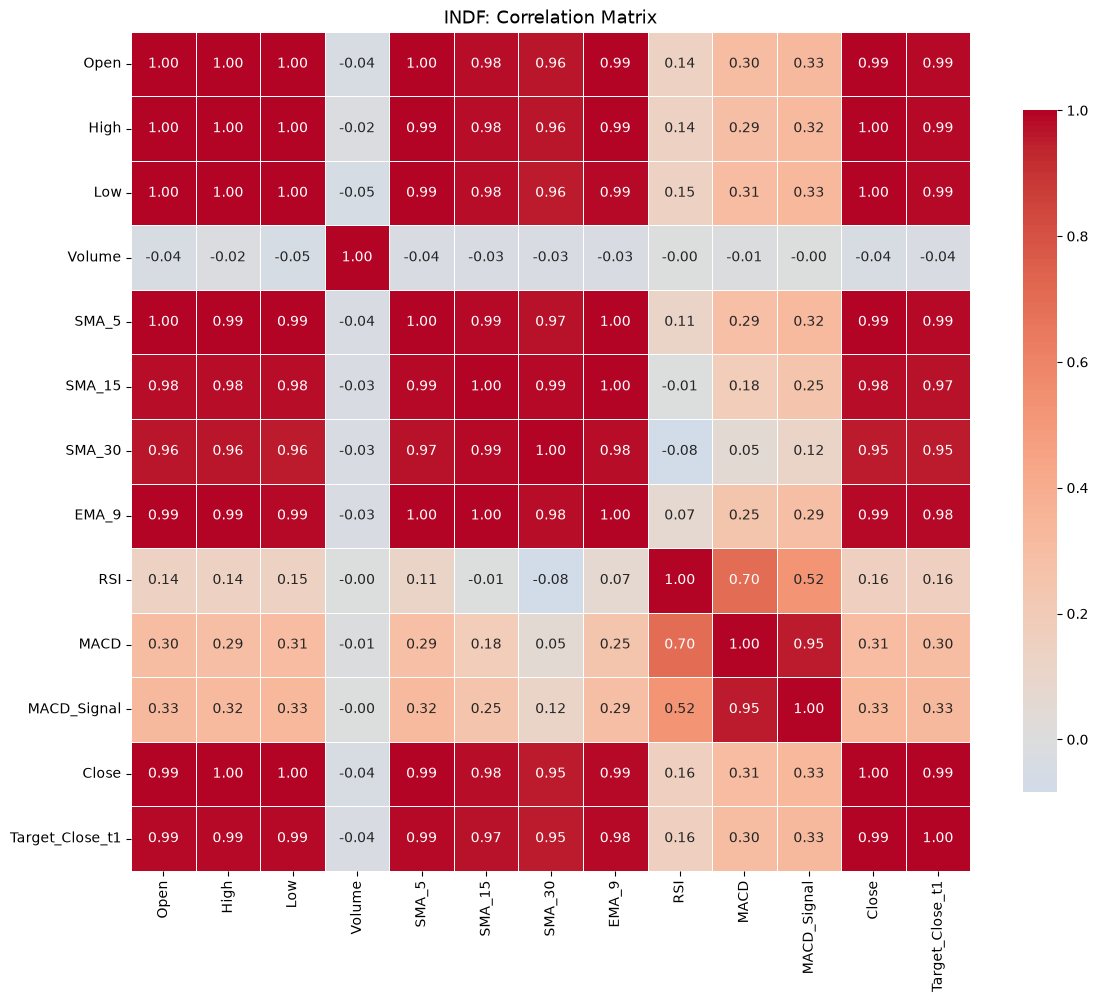


PREPROCESSING SELESAI UNTUK 6 SAHAM
Target alignment: X(t) -> Close(t+1)


In [6]:
print('\n[2] DATA PREPROCESSING...')

# ---------------------------------------------------------------------------
# Technical indicator functions
# ---------------------------------------------------------------------------
def calculate_sma(data, window):
    return data.rolling(window=window).mean()


def calculate_ema(data, span):
    return data.ewm(span=span, adjust=False).mean()


def calculate_rsi(data, period=14):
    delta = data.diff()
    gain = delta.clip(lower=0).rolling(window=period).mean()
    loss = (-delta.clip(upper=0)).rolling(window=period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def calculate_macd(data, fast=12, slow=26, signal=9):
    ema_fast = data.ewm(span=fast, adjust=False).mean()
    ema_slow = data.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    return macd, macd_signal


feature_cols = [
    'Open', 'High', 'Low', 'Volume',
    'SMA_5', 'SMA_15', 'SMA_30', 'EMA_9',
    'RSI', 'MACD', 'MACD_Signal'
]

processed_data = {}

for stock_name, df_raw in raw_data.items():
    ticker = stock_tickers[stock_name]
    print('\n' + '=' * 80)
    print(f'PREPROCESSING {stock_name} ({ticker})')
    print('=' * 80)

    df = df_raw.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    print('\nStatistik Deskriptif Data Awal:')
    print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

    print('\nMembuat indikator teknikal...')
    df['SMA_5'] = calculate_sma(df['Close'], 5)
    df['SMA_15'] = calculate_sma(df['Close'], 15)
    df['SMA_30'] = calculate_sma(df['Close'], 30)
    df['EMA_9'] = calculate_ema(df['Close'], 9)
    df['RSI'] = calculate_rsi(df['Close'], 14)
    df['MACD'], df['MACD_Signal'] = calculate_macd(df['Close'])

    # Reviewer 4: true one-step-ahead target.
    # All features at day t are aligned with the next trading day's Close.
    df['Target_Close_t1'] = df['Close'].shift(-1)

    rows_before = len(df)
    required_cols = feature_cols + ['Close', 'Target_Close_t1']
    df = df.dropna(subset=required_cols).reset_index(drop=True)
    print(f'Baris dengan NaN dihapus: {rows_before - len(df)} baris')
    print(f'Data tersisa: {len(df)} baris')

    # Outliers are diagnosed but NOT removed. Removing price extremes can destroy
    # temporal continuity and, if thresholds are computed globally, can leak future information.
    q1 = df['Close'].quantile(0.25)
    q3 = df['Close'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df['Close'] < lower_bound) | (df['Close'] > upper_bound)
    print('\nOutlier diagnostic (IQR, observations retained):')
    print(f'  Lower bound : {lower_bound:.4f}')
    print(f'  Upper bound : {upper_bound:.4f}')
    print(f'  Detected    : {outlier_mask.sum()} observations')

    # Correlation is diagnostic only; it is not interpreted as causal importance.
    correlation_matrix = df[feature_cols + ['Close', 'Target_Close_t1']].corr()
    print('\nCorrelation with next-day Close target:')
    target_corr = correlation_matrix['Target_Close_t1'].drop('Target_Close_t1').sort_values(ascending=False)
    print(target_corr)

    # -----------------------------------------------------------------------
    # Reviewer-2-compatible figure formatting: no internal grid, visible border,
    # larger labels, legend inside the plotting area.
    # -----------------------------------------------------------------------
    plot_range = slice(-252, None)
    date_range = df['Date'].iloc[plot_range]

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(date_range, df['Close'].iloc[plot_range], label='Close', linewidth=2)
    ax.plot(date_range, df['SMA_5'].iloc[plot_range], label='SMA 5', linewidth=1.5)
    ax.plot(date_range, df['SMA_15'].iloc[plot_range], label='SMA 15', linewidth=1.5)
    ax.plot(date_range, df['SMA_30'].iloc[plot_range], label='SMA 30', linewidth=1.5)
    ax.plot(date_range, df['EMA_9'].iloc[plot_range], label='EMA 9', linewidth=1.5, linestyle='--')
    ax.set_ylabel('Price', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_title(f'{stock_name}: Stock Price with Moving Averages', fontsize=13)
    ax.legend(loc='best', fontsize=10)
    ax.grid(False)
    ax.tick_params(axis='both', labelsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_stock_price_ma.eps', format='eps')
    plt.show()

    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(date_range, df['RSI'].iloc[plot_range], linewidth=1.5, label='RSI')
    ax.axhline(y=70, linestyle='--', label='Overbought (70)', linewidth=1)
    ax.axhline(y=30, linestyle='--', label='Oversold (30)', linewidth=1)
    ax.set_ylabel('RSI', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_title(f'{stock_name}: Relative Strength Index', fontsize=13)
    ax.set_ylim(0, 100)
    ax.legend(loc='best', fontsize=10)
    ax.grid(False)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_rsi_indicator.eps', format='eps')
    plt.show()

    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(date_range, df['MACD'].iloc[plot_range], label='MACD', linewidth=1.5)
    ax.plot(date_range, df['MACD_Signal'].iloc[plot_range], label='Signal', linewidth=1.5)
    ax.axhline(y=0, linewidth=0.8)
    ax.set_ylabel('MACD', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_title(f'{stock_name}: Moving Average Convergence Divergence', fontsize=13)
    ax.legend(loc='best', fontsize=10)
    ax.grid(False)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_macd_indicator.eps', format='eps')
    plt.show()

    fig, ax = plt.subplots(figsize=(15, 4))
    ax.bar(date_range, df['Volume'].iloc[plot_range], alpha=0.7, label='Volume')
    ax.set_ylabel('Volume', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_title(f'{stock_name}: Trade Volume', fontsize=13)
    ax.legend(loc='best', fontsize=10)
    ax.grid(False)
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_trade_volume.eps', format='eps')
    plt.show()

    # Heatmap retained as a multicollinearity diagnostic.
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8}
    )
    plt.title(f'{stock_name}: Correlation Matrix', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_correlation_heatmap.eps', format='eps')
    plt.show()

    processed_data[stock_name] = df.copy()
    df.to_csv(f'{stock_name}_processed.csv', index=False)

print('\n' + '=' * 80)
print('PREPROCESSING SELESAI UNTUK 6 SAHAM')
print('Target alignment: X(t) -> Close(t+1)')
print('=' * 80)


In [8]:
print('\n[3] SPLITTING DATA...')

splits = {}

for stock_name, df in processed_data.items():
    X = df[feature_cols].copy()
    y = df['Target_Close_t1'].copy()

    # Explicit chronological 80:20 split; the final 20% is never used for tuning.
    split_idx = int(len(df) * 0.80)

    X_train = X.iloc[:split_idx].copy()
    X_test = X.iloc[split_idx:].copy()
    y_train = y.iloc[:split_idx].copy()
    y_test = y.iloc[split_idx:].copy()

    train_dates = df['Date'].iloc[:split_idx].copy()
    test_dates = df['Date'].iloc[split_idx:].copy()
    close_t_test = df['Close'].iloc[split_idx:].copy()

    splits[stock_name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'train_dates': train_dates,
        'test_dates': test_dates,
        'close_t_test': close_t_test
    }

    print('\n' + stock_name)
    print(f'  Training set : {len(X_train)} samples')
    print(f'  Testing set  : {len(X_test)} samples')
    print(f'  Train period : {train_dates.iloc[0].date()} to {train_dates.iloc[-1].date()}')
    print(f'  Test period  : {test_dates.iloc[0].date()} to {test_dates.iloc[-1].date()}')

print('\nNo random shuffling is used. The final 20% remains an untouched future test set.')



[3] SPLITTING DATA...

BBCA
  Training set : 1167 samples
  Testing set  : 292 samples
  Train period : 2020-02-12 to 2024-12-05
  Test period  : 2024-12-06 to 2026-03-04

BBRI
  Training set : 1167 samples
  Testing set  : 292 samples
  Train period : 2020-02-12 to 2024-12-05
  Test period  : 2024-12-06 to 2026-03-04

TLKM
  Training set : 1167 samples
  Testing set  : 292 samples
  Train period : 2020-02-12 to 2024-12-05
  Test period  : 2024-12-06 to 2026-03-04

ASII
  Training set : 1167 samples
  Testing set  : 292 samples
  Train period : 2020-02-12 to 2024-12-05
  Test period  : 2024-12-06 to 2026-03-04

ANTM
  Training set : 1167 samples
  Testing set  : 292 samples
  Train period : 2020-02-12 to 2024-12-05
  Test period  : 2024-12-06 to 2026-03-04

INDF
  Training set : 1167 samples
  Testing set  : 292 samples
  Train period : 2020-02-12 to 2024-12-05
  Test period  : 2024-12-06 to 2026-03-04

No random shuffling is used. The final 20% remains an untouched future test set.


## LinearBase


In [9]:
import time

print('\n[4] MODEL TRAINING...')

results_by_stock = {stock: {} for stock in processed_data}


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mape, r2


for stock_name, split in splits.items():
    print('\n' + '=' * 80)
    print(f'{stock_name} - Linear Regression and Random Walk')
    print('=' * 80)

    X_train = split['X_train']
    X_test = split['X_test']
    y_train = split['y_train']
    y_test = split['y_test']

    # -----------------------------------------------------------------------
    # Linear Regression: scaler is fitted only on the training data.
    # -----------------------------------------------------------------------
    lr_pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', LinearRegression())
    ])

    start_time_train = time.time()
    lr_pipeline.fit(X_train, y_train)
    lr_train_time = time.time() - start_time_train

    start_time_pred = time.time()
    y_pred_lr = lr_pipeline.predict(X_test)
    lr_predict_time = time.time() - start_time_pred

    rmse_lr, mae_lr, mape_lr, r2_lr = regression_metrics(y_test, y_pred_lr)

    results_by_stock[stock_name]['Linear Regression'] = {
        'model': lr_pipeline,
        'predictions': y_pred_lr,
        'RMSE': rmse_lr,
        'MAE': mae_lr,
        'MAPE': mape_lr,
        'R2': r2_lr,
        'Train Time': lr_train_time,
        'Prediction Time': lr_predict_time,
        'Tuning Time': 0.0
    }

    # -----------------------------------------------------------------------
    # Random Walk benchmark: Close(t+1)_hat = Close(t)
    # -----------------------------------------------------------------------
    start_time_rw = time.time()
    y_pred_rw = split['close_t_test'].to_numpy(dtype=float)
    rw_predict_time = time.time() - start_time_rw

    rmse_rw, mae_rw, mape_rw, r2_rw = regression_metrics(y_test, y_pred_rw)

    results_by_stock[stock_name]['Random Walk'] = {
        'model': None,
        'predictions': y_pred_rw,
        'RMSE': rmse_rw,
        'MAE': mae_rw,
        'MAPE': mape_rw,
        'R2': r2_rw,
        'Train Time': 0.0,
        'Prediction Time': rw_predict_time,
        'Tuning Time': 0.0
    }

    print('Linear Regression')
    print(f'  RMSE: {rmse_lr:.4f}')
    print(f'  MAE : {mae_lr:.4f}')
    print(f'  MAPE: {mape_lr:.4f}%')
    print(f'  R²  : {r2_lr:.4f}')

    print('Random Walk')
    print(f'  RMSE: {rmse_rw:.4f}')
    print(f'  MAE : {mae_rw:.4f}')
    print(f'  MAPE: {mape_rw:.4f}%')
    print(f'  R²  : {r2_rw:.4f}')



[4] MODEL TRAINING...

BBCA - Linear Regression and Random Walk
Linear Regression
  RMSE: 148.9385
  MAE : 109.7924
  MAPE: 1.3860%
  R²  : 0.9411
Random Walk
  RMSE: 142.5839
  MAE : 106.4812
  MAPE: 1.3404%
  R²  : 0.9460

BBRI - Linear Regression and Random Walk
Linear Regression
  RMSE: 78.8834
  MAE : 58.5252
  MAPE: 1.6883%
  R²  : 0.7990
Random Walk
  RMSE: 75.4489
  MAE : 54.3004
  MAPE: 1.5691%
  R²  : 0.8162

TLKM - Linear Regression and Random Walk
Linear Regression
  RMSE: 71.8013
  MAE : 52.4643
  MAPE: 1.9291%
  R²  : 0.9747
Random Walk
  RMSE: 68.7245
  MAE : 49.7918
  MAPE: 1.8385%
  R²  : 0.9768

ASII - Linear Regression and Random Walk
Linear Regression
  RMSE: 119.9231
  MAE : 82.7756
  MAPE: 1.5755%
  R²  : 0.9824
Random Walk
  RMSE: 115.2905
  MAE : 77.7282
  MAPE: 1.4930%
  R²  : 0.9838

ANTM - Linear Regression and Random Walk
Linear Regression
  RMSE: 103.0688
  MAE : 73.1435
  MAPE: 2.7619%
  R²  : 0.9850
Random Walk
  RMSE: 97.9764
  MAE : 68.6747
  MAPE: 2.6

## GridSearch


In [10]:
import time

# ---------------------------------------------------------------------------
# XGBOOST - time-aware hyperparameter selection
# ---------------------------------------------------------------------------
print('\n--- XGBoost: TimeSeriesSplit Grid Search ---')

xgb_param_grid = {
    'model__n_estimators': [100, 200, 400],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 8, 12],
    'model__gamma': [0.001, 0.01]
}

best_xgb_params_by_stock = {}
xgb_tuning_time_by_stock = {}

for stock_name, split in splits.items():
    print('\n' + '=' * 80)
    print(f'XGBoost Grid Search - {stock_name}')
    print('=' * 80)

    # Expanding-window time-series CV. Validation always occurs after training.
    tscv = TimeSeriesSplit(n_splits=3)

    xgb_pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', xgb.XGBRegressor(
            random_state=42,
            objective='reg:squarederror',
            n_jobs=1
        ))
    ])

    xgb_grid = GridSearchCV(
        estimator=xgb_pipeline,
        param_grid=xgb_param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0,
        refit=True
    )

    start_time = time.time()
    xgb_grid.fit(split['X_train'], split['y_train'])
    tuning_time = time.time() - start_time

    # Remove Pipeline prefix before reusing the parameters in the fixed-model cell.
    clean_params = {
        key.replace('model__', ''): value
        for key, value in xgb_grid.best_params_.items()
    }

    best_xgb_params_by_stock[stock_name] = clean_params
    xgb_tuning_time_by_stock[stock_name] = tuning_time

    print('Best parameters:', clean_params)
    print(f'Best CV RMSE   : {-xgb_grid.best_score_:.4f}')
    print(f'Tuning time   : {tuning_time:.4f} seconds')



--- XGBoost: TimeSeriesSplit Grid Search ---

XGBoost Grid Search - BBCA
Best parameters: {'gamma': 0.001, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV RMSE   : 771.5688
Tuning time   : 23.7457 seconds

XGBoost Grid Search - BBRI
Best parameters: {'gamma': 0.001, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400}
Best CV RMSE   : 312.3430
Tuning time   : 17.7846 seconds

XGBoost Grid Search - TLKM
Best parameters: {'gamma': 0.001, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400}
Best CV RMSE   : 230.4978
Tuning time   : 16.0254 seconds

XGBoost Grid Search - ASII
Best parameters: {'gamma': 0.001, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV RMSE   : 154.3468
Tuning time   : 17.8794 seconds

XGBoost Grid Search - ANTM
Best parameters: {'gamma': 0.001, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 400}
Best CV RMSE   : 78.0468
Tuning time   : 14.4294 seconds

XGBoost Grid Search - INDF
Best parameters: {'gamma': 0.

In [11]:
import time

# ---------------------------------------------------------------------------
# LIGHTGBM - time-aware hyperparameter selection
# ---------------------------------------------------------------------------
print('\n--- LightGBM: TimeSeriesSplit Grid Search ---')

lgb_param_grid = {
    'model__n_estimators': [100, 200, 400],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 8, 12],
    'model__num_leaves': [31, 50, 70],
    'model__boosting_type': ['gbdt', 'dart']
}

best_lgb_params_by_stock = {}
lgb_tuning_time_by_stock = {}

for stock_name, split in splits.items():
    print('\n' + '=' * 80)
    print(f'LightGBM Grid Search - {stock_name}')
    print('=' * 80)

    tscv = TimeSeriesSplit(n_splits=3)

    lgb_pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', lgb.LGBMRegressor(
            random_state=42,
            verbose=-1,
            n_jobs=1
        ))
    ])

    lgb_grid = GridSearchCV(
        estimator=lgb_pipeline,
        param_grid=lgb_param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0,
        refit=True
    )

    start_time = time.time()
    lgb_grid.fit(split['X_train'], split['y_train'])
    tuning_time = time.time() - start_time

    clean_params = {
        key.replace('model__', ''): value
        for key, value in lgb_grid.best_params_.items()
    }

    best_lgb_params_by_stock[stock_name] = clean_params
    lgb_tuning_time_by_stock[stock_name] = tuning_time

    print('Best parameters:', clean_params)
    print(f'Best CV RMSE   : {-lgb_grid.best_score_:.4f}')
    print(f'Tuning time   : {tuning_time:.4f} seconds')



--- LightGBM: TimeSeriesSplit Grid Search ---

LightGBM Grid Search - BBCA
Best parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400, 'num_leaves': 31}
Best CV RMSE   : 759.4352
Tuning time   : 6.1871 seconds

LightGBM Grid Search - BBRI
Best parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.05, 'max_depth': 12, 'n_estimators': 200, 'num_leaves': 31}
Best CV RMSE   : 319.0844
Tuning time   : 6.1489 seconds

LightGBM Grid Search - TLKM
Best parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 31}
Best CV RMSE   : 232.9633
Tuning time   : 6.3393 seconds

LightGBM Grid Search - ASII
Best parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'num_leaves': 31}
Best CV RMSE   : 166.3412
Tuning time   : 6.0945 seconds

LightGBM Grid Search - ANTM
Best parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators

## Fixed Param Boosting


In [12]:
import time

print('\n--- XGBoost with Selected Parameters ---')

for stock_name, split in splits.items():
    print('\n' + '=' * 80)
    print(f'Final XGBoost - {stock_name}')
    print('=' * 80)

    best_xgb_params = best_xgb_params_by_stock[stock_name]

    fixed_xgb_pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', xgb.XGBRegressor(
            random_state=42,
            objective='reg:squarederror',
            n_jobs=-1,
            **best_xgb_params
        ))
    ])

    start_time_train = time.time()
    fixed_xgb_pipeline.fit(split['X_train'], split['y_train'])
    train_time = time.time() - start_time_train

    start_time_pred = time.time()
    y_pred_xgb = fixed_xgb_pipeline.predict(split['X_test'])
    predict_time = time.time() - start_time_pred

    rmse, mae, mape, r2 = regression_metrics(split['y_test'], y_pred_xgb)

    results_by_stock[stock_name]['XGBoost'] = {
        'model': fixed_xgb_pipeline,
        'predictions': y_pred_xgb,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2,
        'Train Time': train_time,
        'Prediction Time': predict_time,
        'Tuning Time': xgb_tuning_time_by_stock[stock_name],
        'Best Params': best_xgb_params
    }

    print(f'RMSE: {rmse:.4f}')
    print(f'MAE : {mae:.4f}')
    print(f'MAPE: {mape:.4f}%')
    print(f'R²  : {r2:.4f}')
    print(f'Final train time: {train_time:.4f} seconds')
    print(f'Tuning time     : {xgb_tuning_time_by_stock[stock_name]:.4f} seconds')



--- XGBoost with Selected Parameters ---

Final XGBoost - BBCA
RMSE: 162.9849
MAE : 121.6890
MAPE: 1.5448%
R²  : 0.9295
Final train time: 0.6864 seconds
Tuning time     : 23.7457 seconds

Final XGBoost - BBRI
RMSE: 83.9457
MAE : 64.0057
MAPE: 1.8457%
R²  : 0.7724
Final train time: 0.4781 seconds
Tuning time     : 17.7846 seconds

Final XGBoost - TLKM
RMSE: 75.9182
MAE : 56.3120
MAPE: 2.1040%
R²  : 0.9717
Final train time: 0.3796 seconds
Tuning time     : 16.0254 seconds

Final XGBoost - ASII
RMSE: 587.8326
MAE : 369.8123
MAPE: 6.1636%
R²  : 0.5783
Final train time: 0.1831 seconds
Tuning time     : 17.8794 seconds

Final XGBoost - ANTM
RMSE: 878.2589
MAE : 674.2269
MAPE: 21.6062%
R²  : -0.0878
Final train time: 0.5288 seconds
Tuning time     : 14.4294 seconds

Final XGBoost - INDF
RMSE: 321.7793
MAE : 228.8745
MAPE: 3.1169%
R²  : 0.5412
Final train time: 0.0588 seconds
Tuning time     : 17.9264 seconds


In [13]:
import time

print('\n--- LightGBM with Selected Parameters ---')

for stock_name, split in splits.items():
    print('\n' + '=' * 80)
    print(f'Final LightGBM - {stock_name}')
    print('=' * 80)

    best_lgb_params = best_lgb_params_by_stock[stock_name]

    fixed_lgb_pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', lgb.LGBMRegressor(
            random_state=42,
            verbose=-1,
            n_jobs=-1,
            **best_lgb_params
        ))
    ])

    start_time_train = time.time()
    fixed_lgb_pipeline.fit(split['X_train'], split['y_train'])
    train_time = time.time() - start_time_train

    start_time_pred = time.time()
    y_pred_lgb = fixed_lgb_pipeline.predict(split['X_test'])
    predict_time = time.time() - start_time_pred

    rmse, mae, mape, r2 = regression_metrics(split['y_test'], y_pred_lgb)

    results_by_stock[stock_name]['LightGBM'] = {
        'model': fixed_lgb_pipeline,
        'predictions': y_pred_lgb,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2,
        'Train Time': train_time,
        'Prediction Time': predict_time,
        'Tuning Time': lgb_tuning_time_by_stock[stock_name],
        'Best Params': best_lgb_params
    }

    print(f'RMSE: {rmse:.4f}')
    print(f'MAE : {mae:.4f}')
    print(f'MAPE: {mape:.4f}%')
    print(f'R²  : {r2:.4f}')
    print(f'Final train time: {train_time:.4f} seconds')
    print(f'Tuning time     : {lgb_tuning_time_by_stock[stock_name]:.4f} seconds')



--- LightGBM with Selected Parameters ---

Final LightGBM - BBCA
RMSE: 171.0891
MAE : 130.1482
MAPE: 1.6600%
R²  : 0.9223
Final train time: 0.5348 seconds
Tuning time     : 6.1871 seconds

Final LightGBM - BBRI
RMSE: 85.4367
MAE : 64.6346
MAPE: 1.8663%
R²  : 0.7643
Final train time: 1.1090 seconds
Tuning time     : 6.1489 seconds

Final LightGBM - TLKM
RMSE: 73.4425
MAE : 55.3634
MAPE: 2.0730%
R²  : 0.9735
Final train time: 0.2520 seconds
Tuning time     : 6.3393 seconds

Final LightGBM - ASII
RMSE: 591.1958
MAE : 372.5639
MAPE: 6.2105%
R²  : 0.5735
Final train time: 0.1560 seconds
Tuning time     : 6.0945 seconds

Final LightGBM - ANTM
RMSE: 852.9692
MAE : 651.9378
MAPE: 20.8665%
R²  : -0.0261
Final train time: 0.5566 seconds
Tuning time     : 6.2801 seconds

Final LightGBM - INDF
RMSE: 356.6278
MAE : 270.8397
MAPE: 3.7311%
R²  : 0.4365
Final train time: 0.0745 seconds
Tuning time     : 6.4008 seconds


## Result


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



PERBANDINGAN HASIL MODEL

Combined result table:
Stock             Model       RMSE        MAE  MAPE (%)        R2  RMSE Improvement vs RW (%)  MAE Improvement vs RW (%)  MAPE Improvement vs RW (%)  Train Time (s)  Prediction Time (s)  Tuning Time (s)
 BBCA       Random Walk 142.583943 106.481235  1.340371  0.946008                    0.000000                   0.000000                    0.000000        0.000000             0.000036         0.000000
 BBCA Linear Regression 148.938474 109.792350  1.386034  0.941088                   -4.456694                  -3.109577                   -3.406767        0.050859             0.002234         0.000000
 BBCA           XGBoost 162.984938 121.688963  1.544775  0.929452                  -14.308059                 -14.282074                  -15.249815        0.686389             0.001889        23.745716
 BBCA          LightGBM 171.089144 130.148168  1.659969  0.922262                  -19.991873                 -22.226389                  

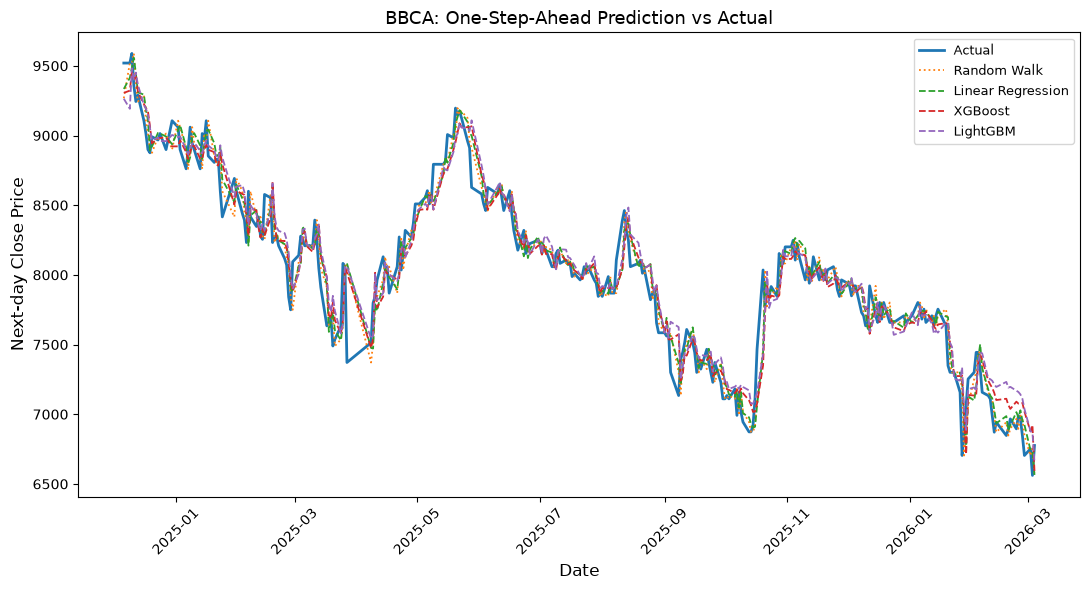

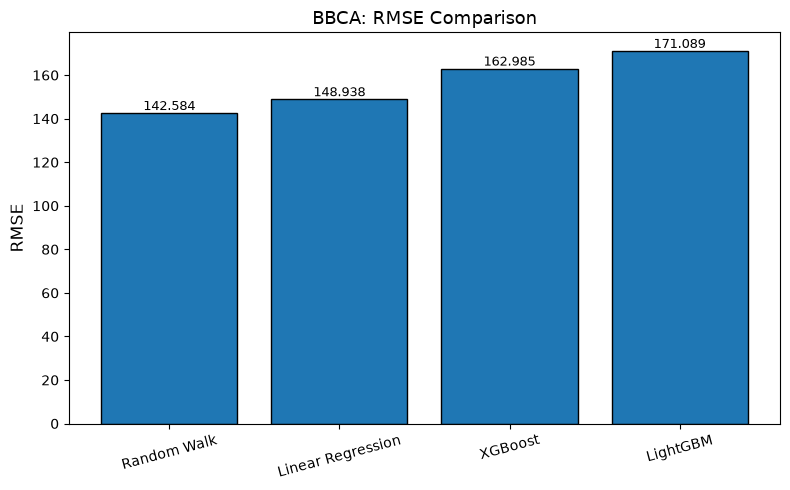

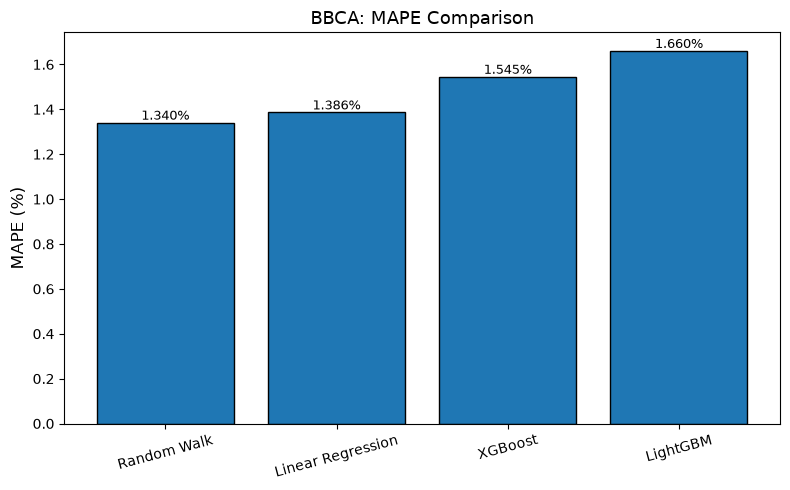

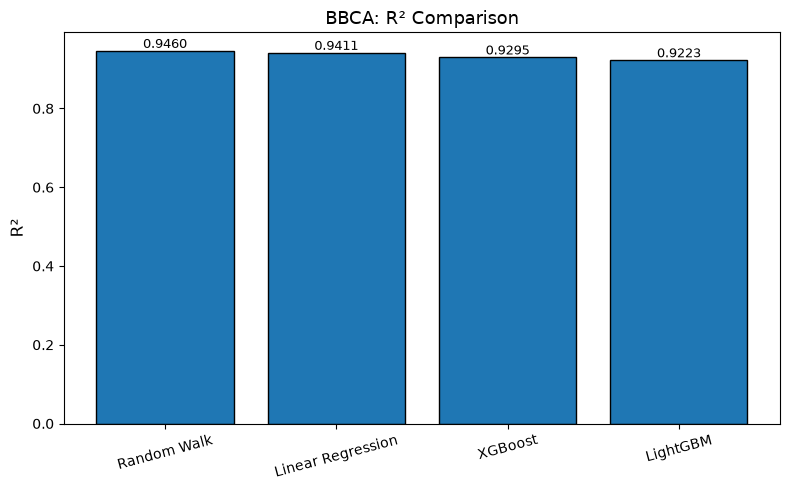

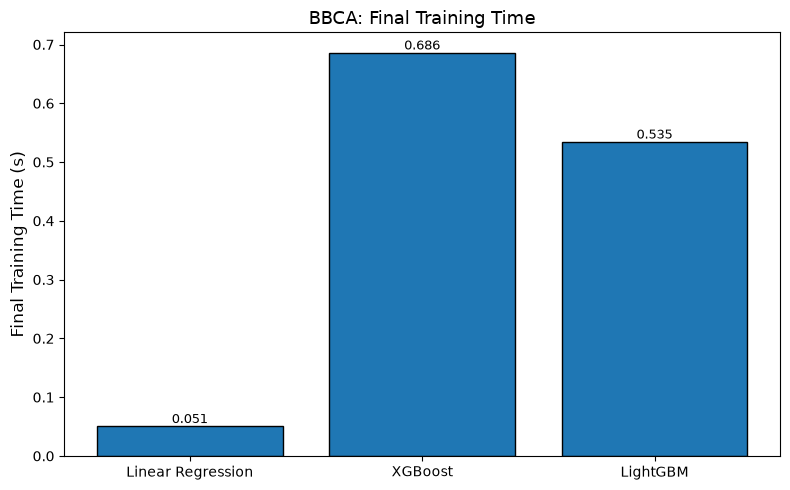

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


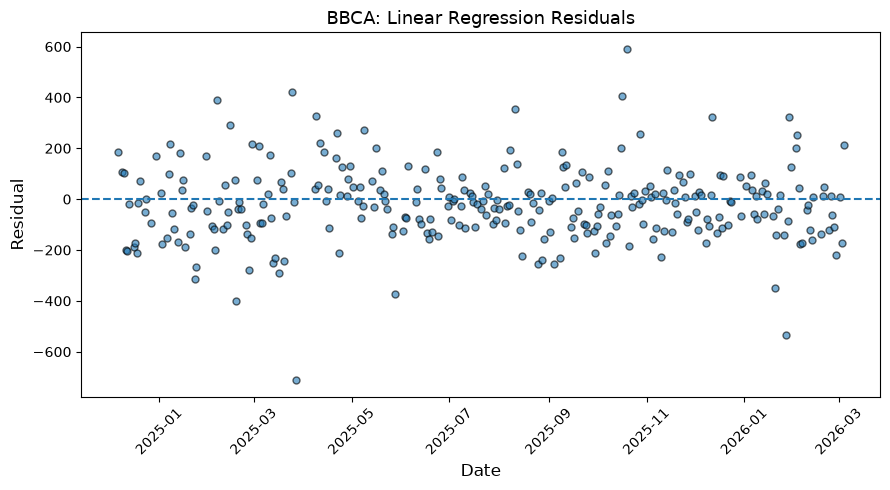

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


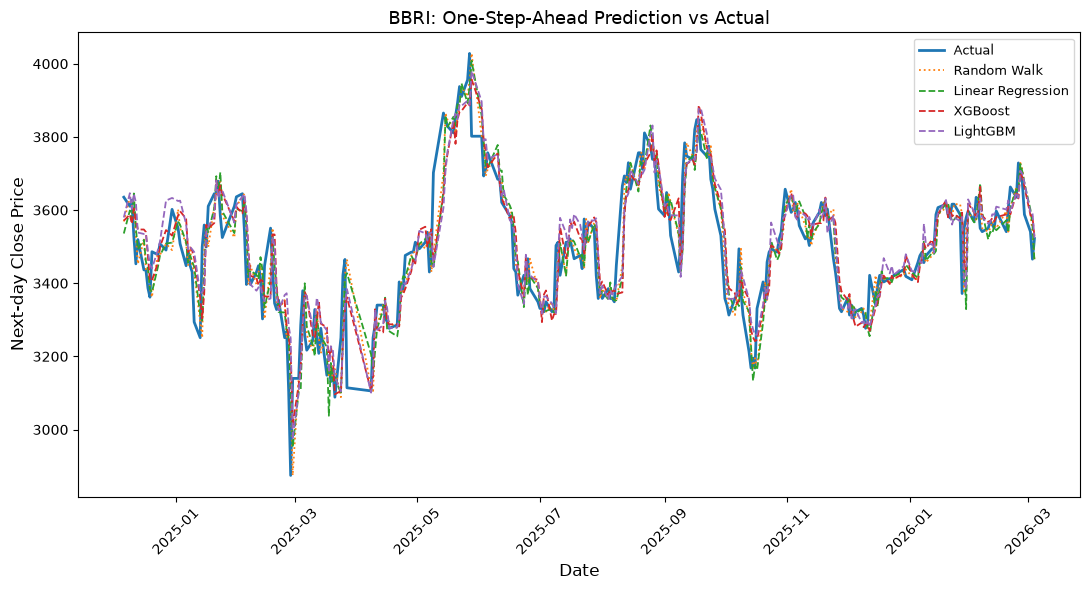

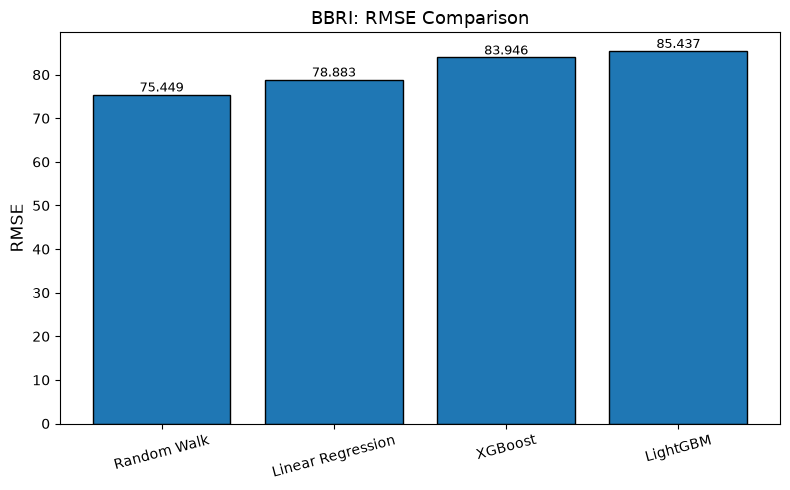

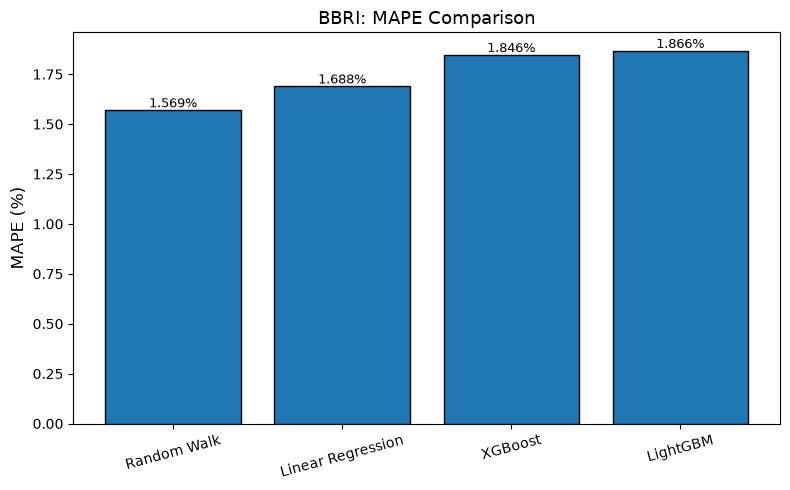

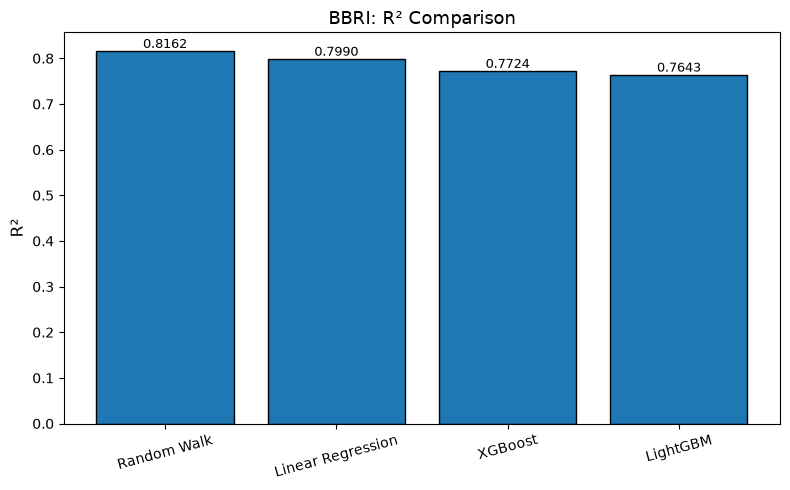

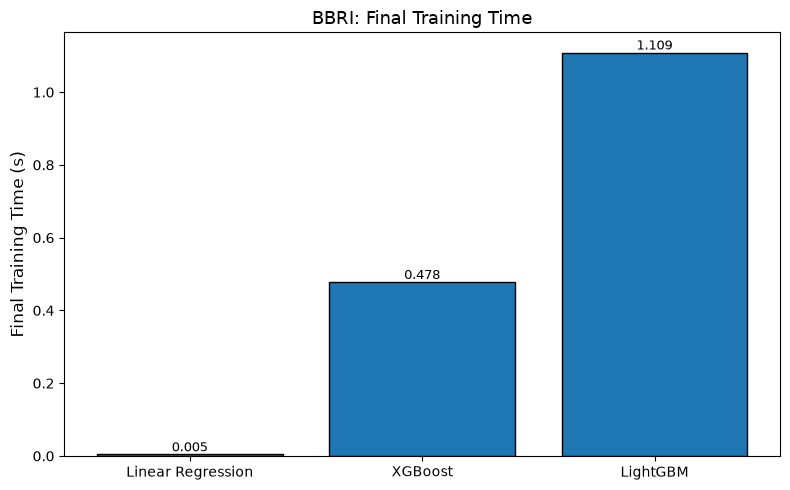

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


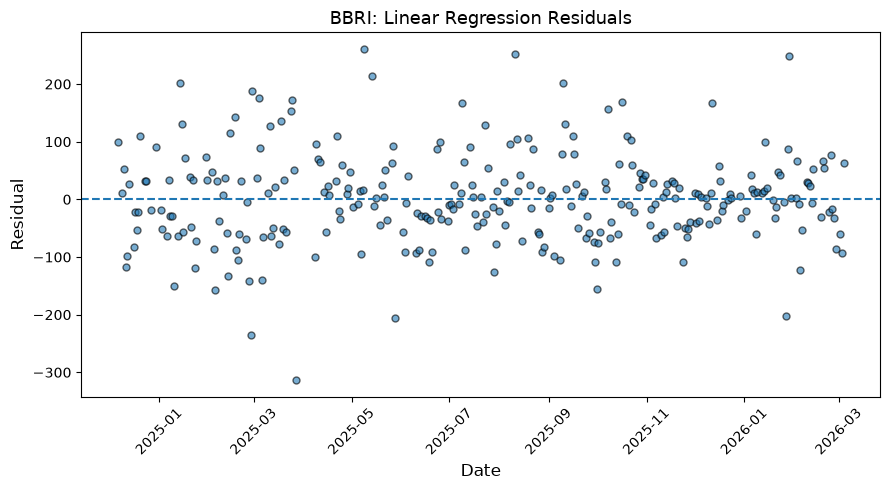

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


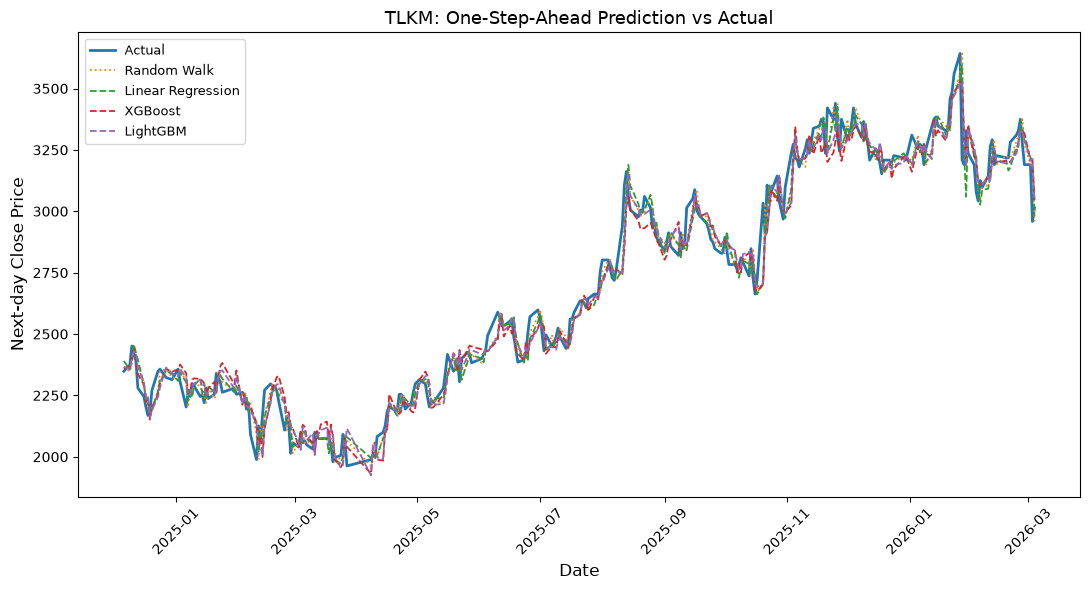

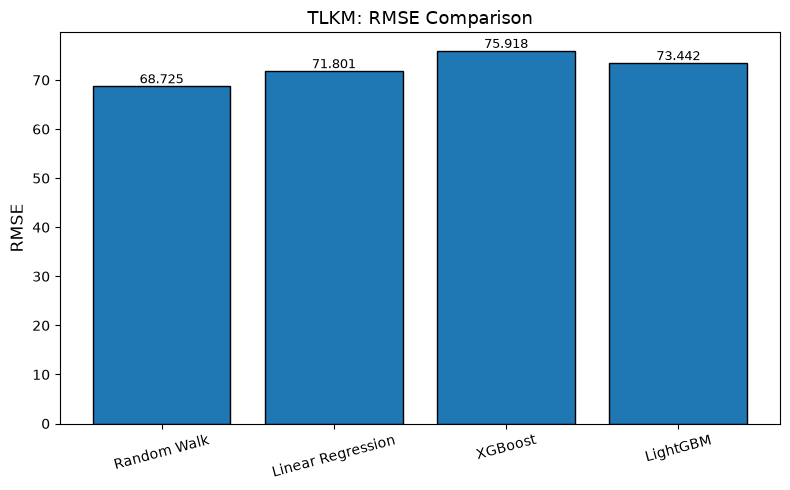

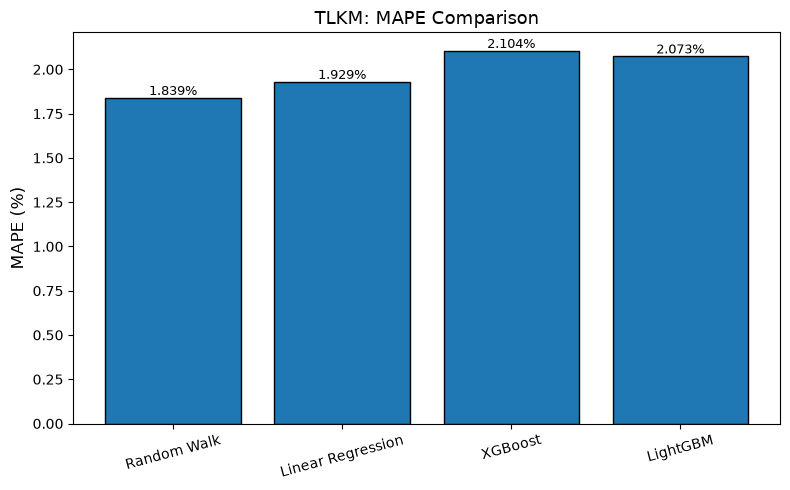

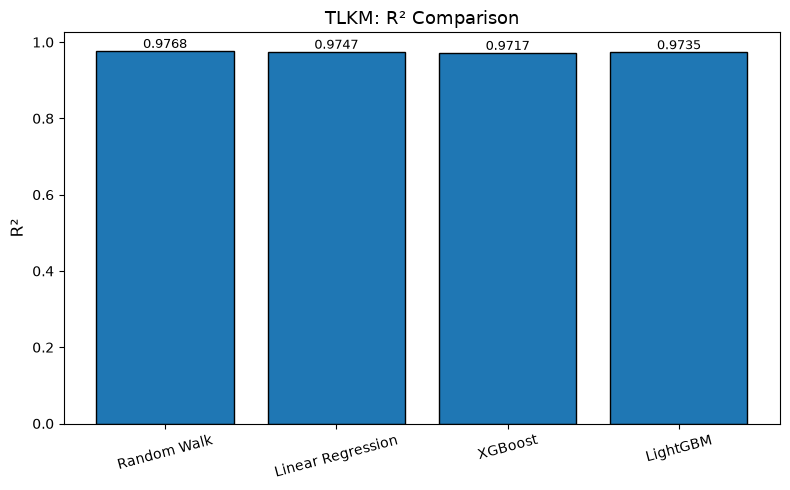

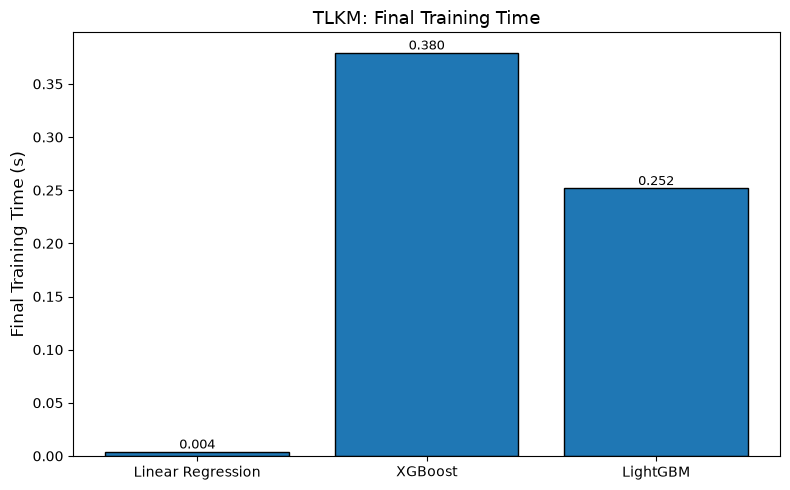

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


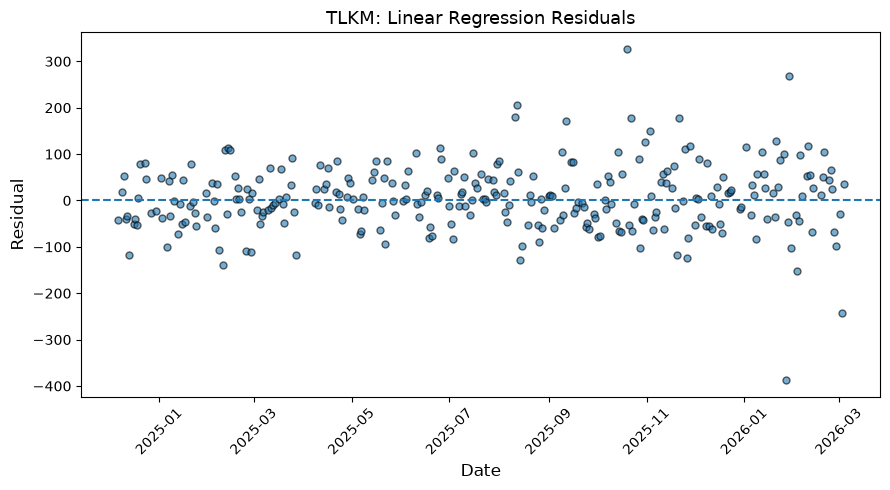

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


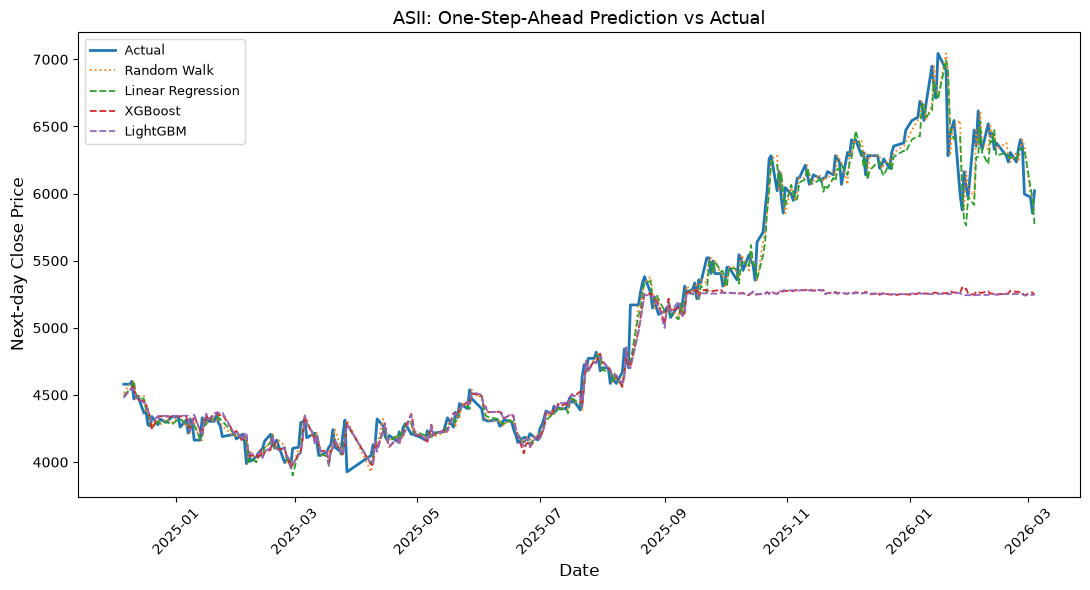

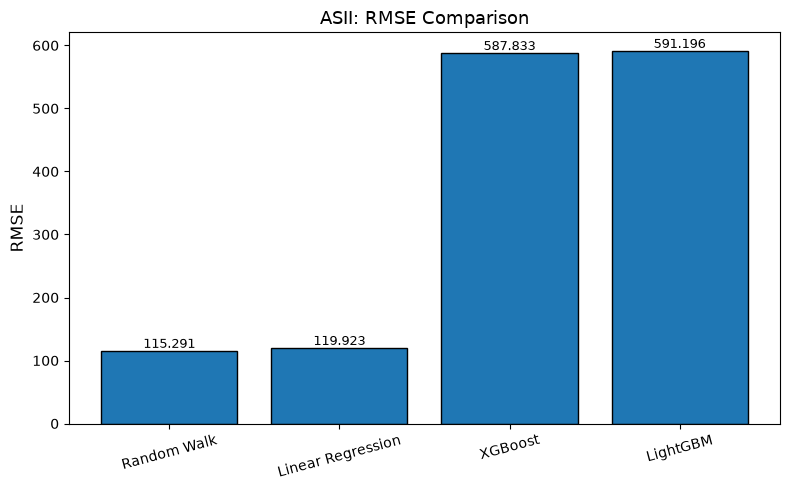

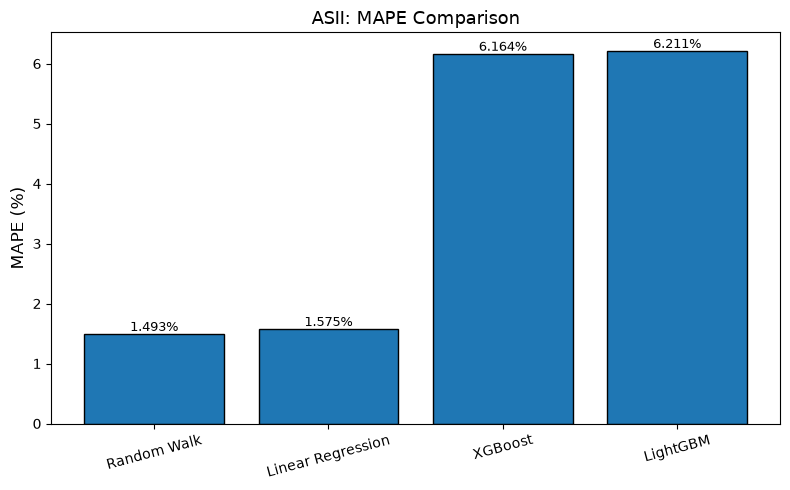

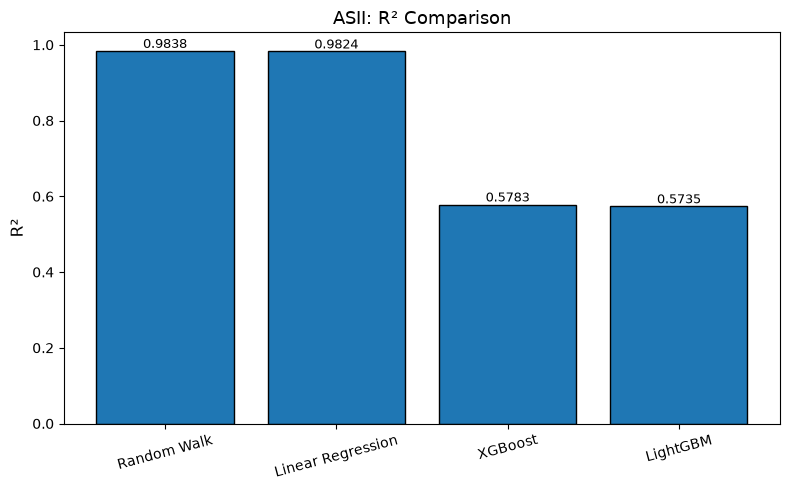

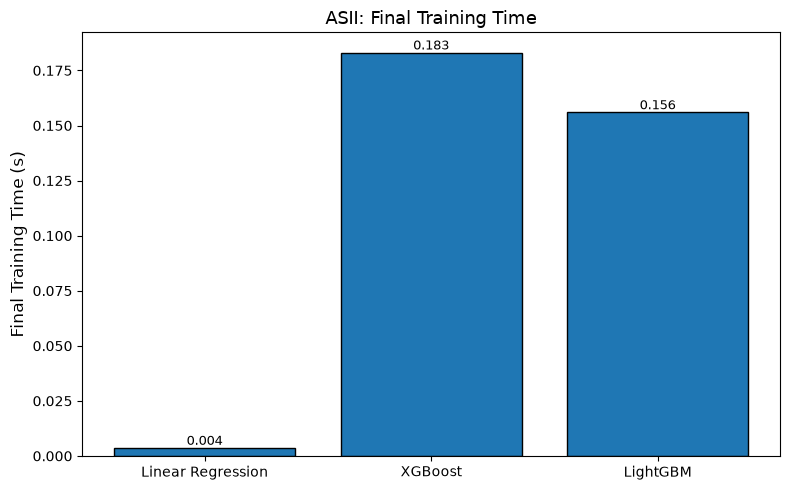

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


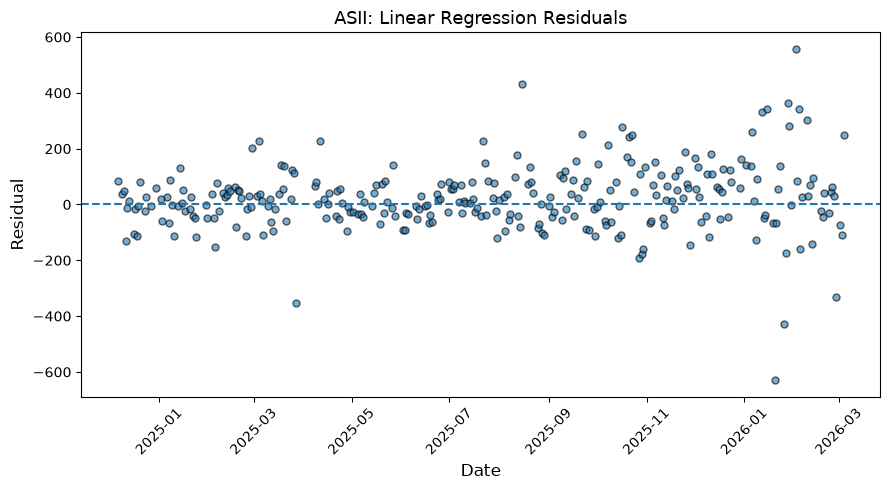

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


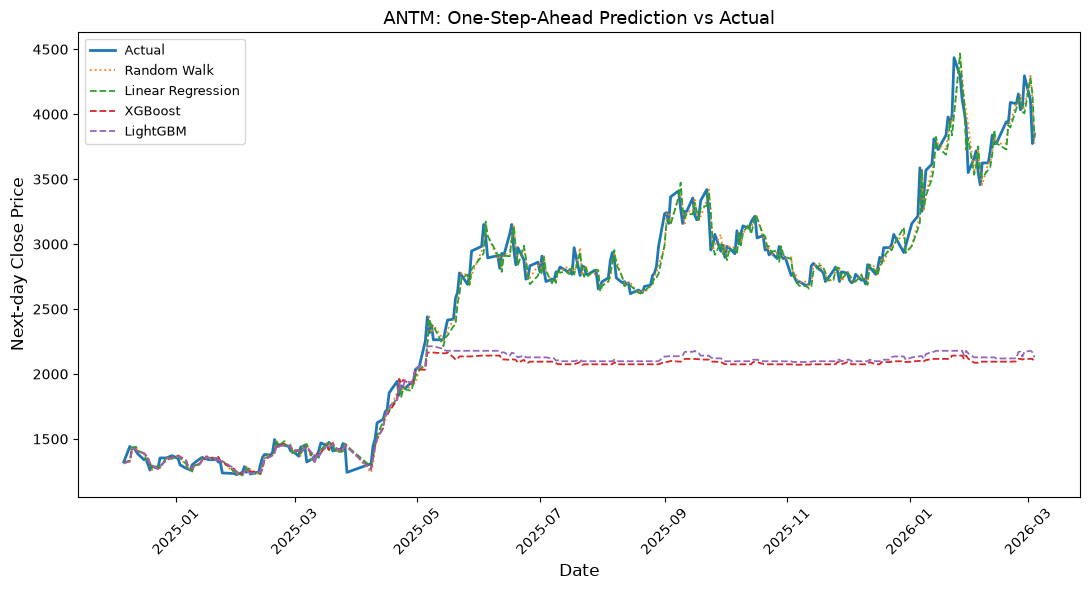

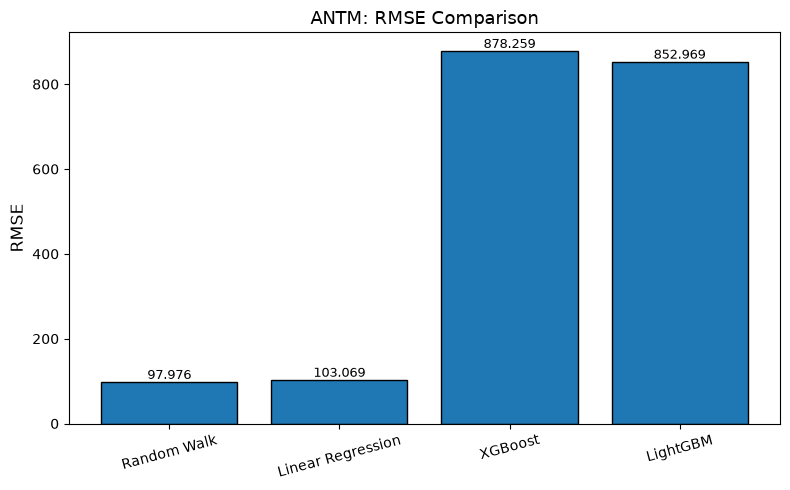

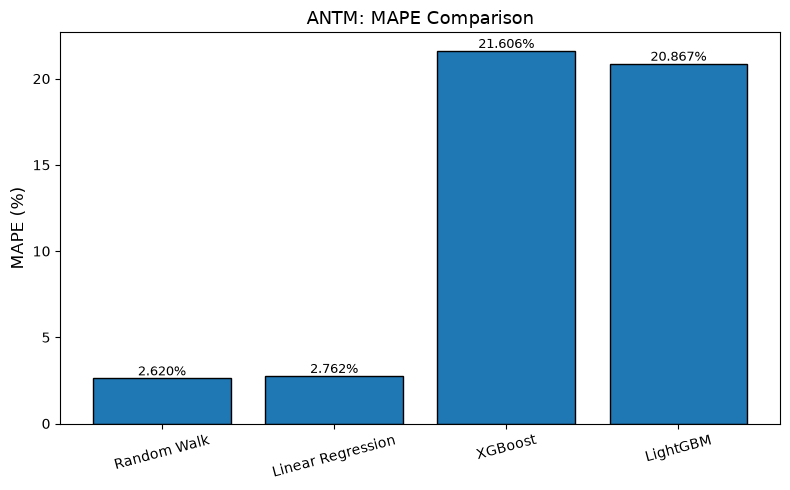

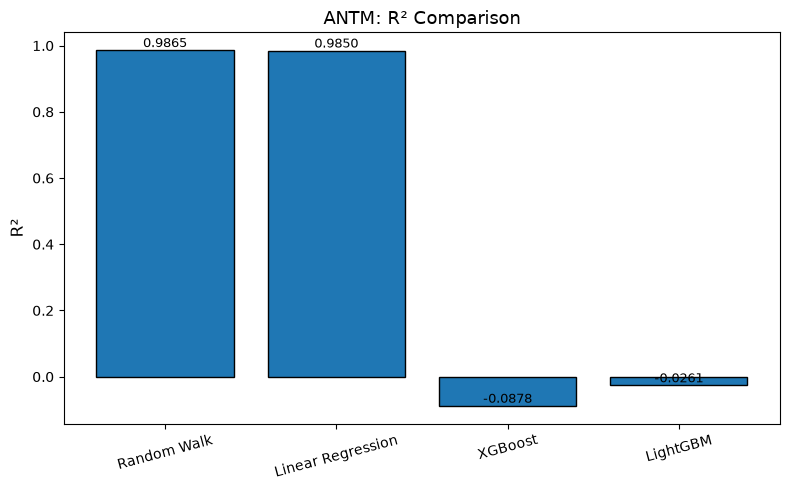

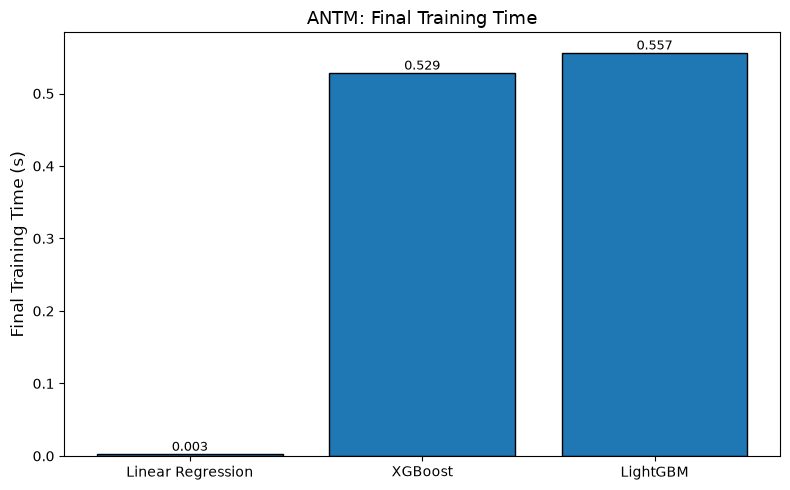

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


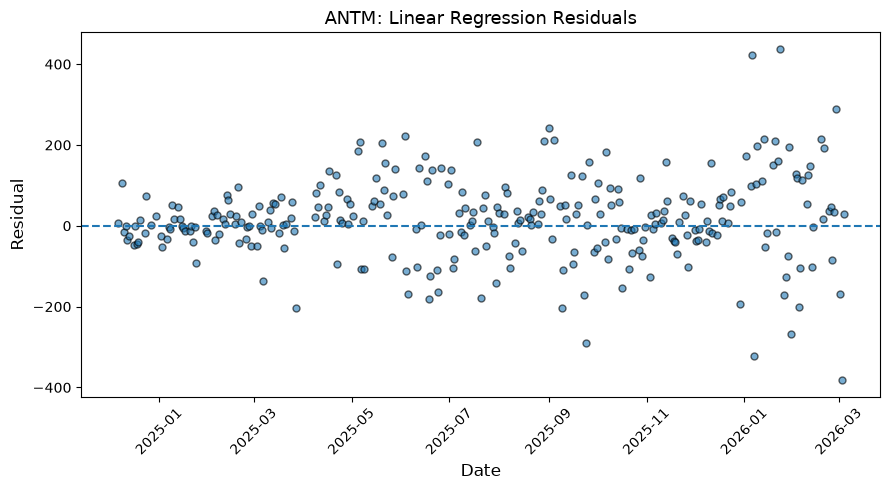

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


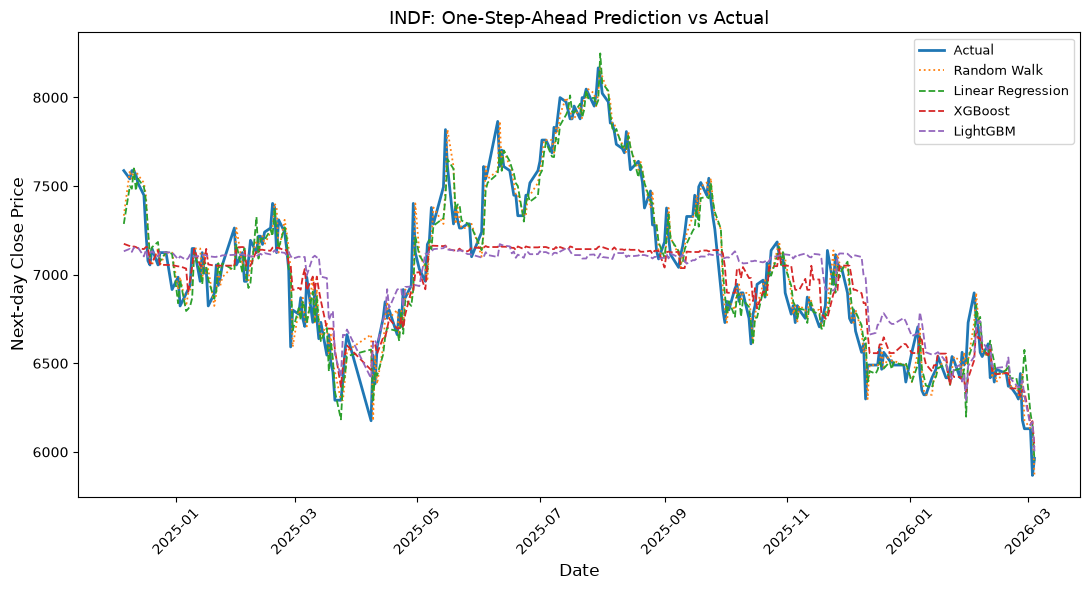

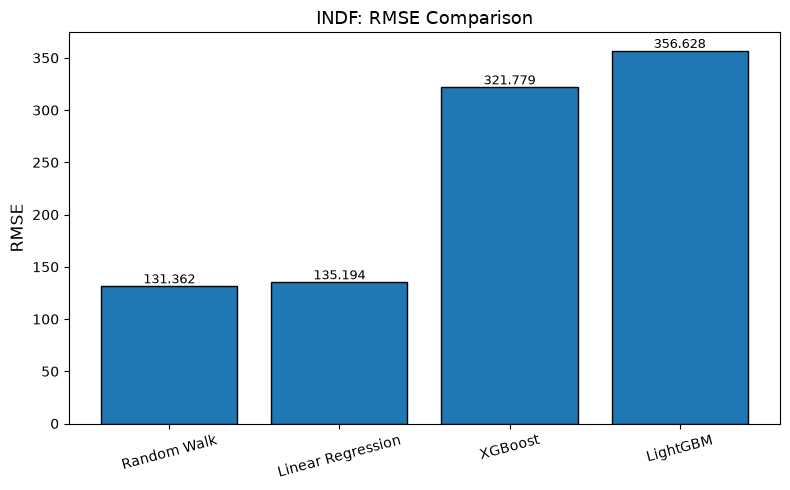

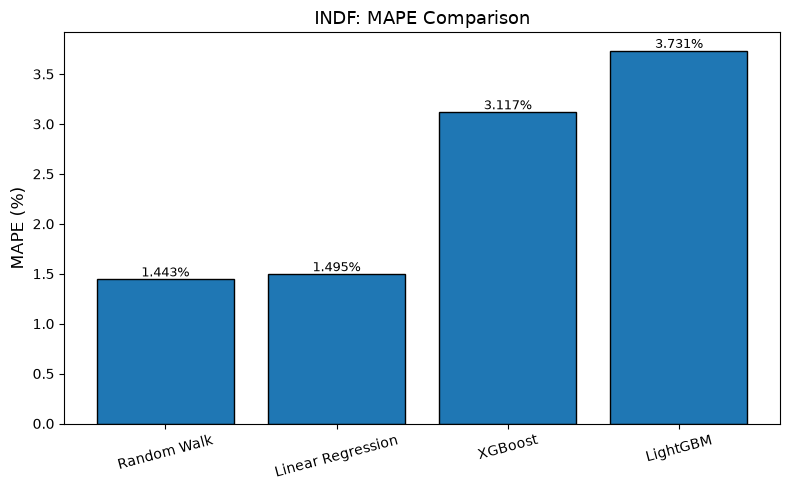

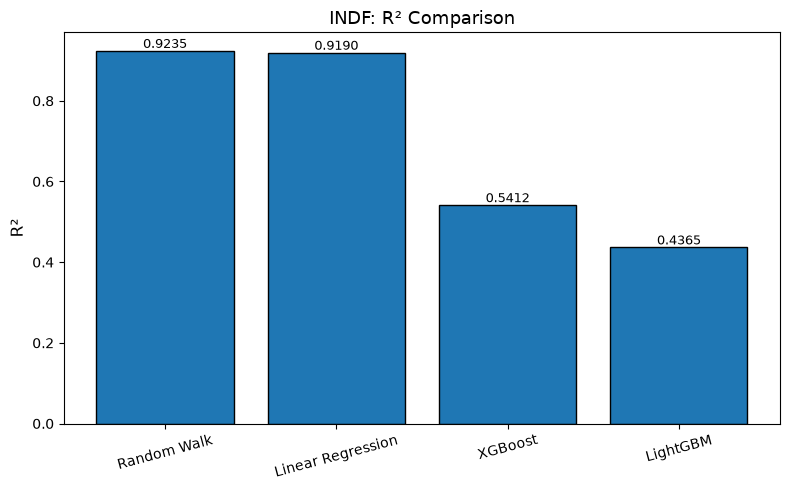

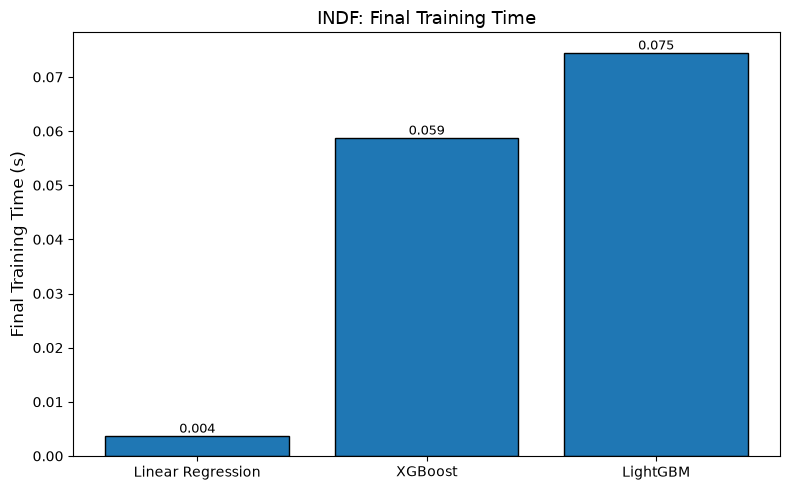

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


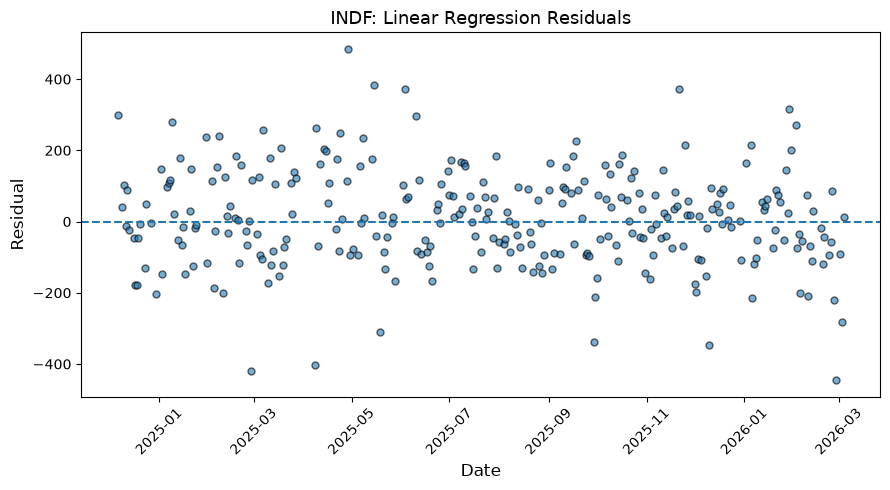

In [14]:
print('\n' + '=' * 80)
print('PERBANDINGAN HASIL MODEL')
print('=' * 80)

model_order = ['Random Walk', 'Linear Regression', 'XGBoost', 'LightGBM']
all_result_rows = []

for stock_name in stock_tickers:
    rw = results_by_stock[stock_name]['Random Walk']

    for model_name in model_order:
        res = results_by_stock[stock_name][model_name]

        if model_name == 'Random Walk':
            rmse_improvement = 0.0
            mae_improvement = 0.0
            mape_improvement = 0.0
        else:
            rmse_improvement = (rw['RMSE'] - res['RMSE']) / rw['RMSE'] * 100
            mae_improvement = (rw['MAE'] - res['MAE']) / rw['MAE'] * 100
            mape_improvement = (rw['MAPE'] - res['MAPE']) / rw['MAPE'] * 100

        all_result_rows.append({
            'Stock': stock_name,
            'Model': model_name,
            'RMSE': res['RMSE'],
            'MAE': res['MAE'],
            'MAPE (%)': res['MAPE'],
            'R2': res['R2'],
            'RMSE Improvement vs RW (%)': rmse_improvement,
            'MAE Improvement vs RW (%)': mae_improvement,
            'MAPE Improvement vs RW (%)': mape_improvement,
            'Train Time (s)': res['Train Time'],
            'Prediction Time (s)': res['Prediction Time'],
            'Tuning Time (s)': res.get('Tuning Time', 0.0)
        })

comparison_df = pd.DataFrame(all_result_rows)
comparison_df.to_csv('all_stock_model_results.csv', index=False)

print('\nCombined result table:')
print(comparison_df.to_string(index=False))
print('\nSaved: all_stock_model_results.csv')

# ---------------------------------------------------------------------------
# Diebold-Mariano test with squared-error loss and Harvey small-sample correction.
# For h=1, a negative mean loss differential means model_1 has lower MSE.
# ---------------------------------------------------------------------------
def diebold_mariano_test(y_true, pred_1, pred_2, h=1):
    y_true = np.asarray(y_true, dtype=float)
    pred_1 = np.asarray(pred_1, dtype=float)
    pred_2 = np.asarray(pred_2, dtype=float)

    e1 = y_true - pred_1
    e2 = y_true - pred_2
    d = e1**2 - e2**2
    n = len(d)

    mean_d = np.mean(d)
    gamma0 = np.var(d, ddof=1)

    if not np.isfinite(gamma0) or gamma0 <= 0 or n <= 2:
        return np.nan, np.nan, mean_d

    # For one-step-ahead forecasts (h=1), no higher autocovariance term is required.
    dm_stat = mean_d / np.sqrt(gamma0 / n)

    # Harvey-Leybourne-Newbold small-sample correction.
    correction = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm_stat_hln = dm_stat * correction
    p_value = 2 * stats.t.sf(np.abs(dm_stat_hln), df=n - 1)

    return dm_stat_hln, p_value, mean_d


dm_pairs = [
    ('Linear Regression', 'Random Walk'),
    ('XGBoost', 'Random Walk'),
    ('LightGBM', 'Random Walk'),
    ('Linear Regression', 'XGBoost'),
    ('Linear Regression', 'LightGBM')
]

dm_rows = []
for stock_name, split in splits.items():
    y_true = split['y_test'].to_numpy(dtype=float)

    for model_1, model_2 in dm_pairs:
        pred_1 = results_by_stock[stock_name][model_1]['predictions']
        pred_2 = results_by_stock[stock_name][model_2]['predictions']
        dm_stat, p_value, mean_loss_diff = diebold_mariano_test(y_true, pred_1, pred_2, h=1)

        dm_rows.append({
            'Stock': stock_name,
            'Model 1': model_1,
            'Model 2': model_2,
            'DM Statistic': dm_stat,
            'p-value': p_value,
            'Mean Loss Difference (M1-M2)': mean_loss_diff,
            'Significant at 5%': bool(p_value < 0.05) if np.isfinite(p_value) else False
        })


dm_df = pd.DataFrame(dm_rows)
dm_df.to_csv('diebold_mariano_results.csv', index=False)

print('\n' + '=' * 80)
print('DIEBOLD-MARIANO TEST RESULTS')
print('Negative mean loss difference => Model 1 has lower squared-error loss.')
print('=' * 80)
print(dm_df.to_string(index=False))
print('\nSaved: diebold_mariano_results.csv')

# ---------------------------------------------------------------------------
# Figures per stock. Coefficient-ranking / OLS feature-importance plot removed
# because Reviewer 4 correctly notes that coefficients are unstable under severe
# multicollinearity and should not be interpreted as economic drivers.
# ---------------------------------------------------------------------------
for stock_name, split in splits.items():
    test_dates = split['test_dates'].to_numpy()
    y_test = split['y_test'].to_numpy(dtype=float)

    # Prediction vs actual
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(test_dates, y_test, label='Actual', linewidth=2)
    for model_name in model_order:
        ax.plot(
            test_dates,
            results_by_stock[stock_name][model_name]['predictions'],
            label=model_name,
            linewidth=1.3,
            linestyle='--' if model_name != 'Random Walk' else ':'
        )
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Next-day Close Price', fontsize=12)
    ax.set_title(f'{stock_name}: One-Step-Ahead Prediction vs Actual', fontsize=13)
    ax.legend(loc='best', fontsize=9)
    ax.grid(False)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_prediction_vs_actual.eps', format='eps')
    plt.show()

    # RMSE comparison
    rmse_values = [results_by_stock[stock_name][m]['RMSE'] for m in model_order]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(model_order, rmse_values, edgecolor='black')
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title(f'{stock_name}: RMSE Comparison', fontsize=13)
    ax.grid(False)
    ax.tick_params(axis='x', labelrotation=15)
    for bar, value in zip(bars, rmse_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.3f}',
                ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_rmse_comparison.eps', format='eps')
    plt.show()

    # MAPE comparison
    mape_values = [results_by_stock[stock_name][m]['MAPE'] for m in model_order]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(model_order, mape_values, edgecolor='black')
    ax.set_ylabel('MAPE (%)', fontsize=12)
    ax.set_title(f'{stock_name}: MAPE Comparison', fontsize=13)
    ax.grid(False)
    ax.tick_params(axis='x', labelrotation=15)
    for bar, value in zip(bars, mape_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.3f}%',
                ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_mape_comparison.eps', format='eps')
    plt.show()

    # R2 comparison
    r2_values = [results_by_stock[stock_name][m]['R2'] for m in model_order]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(model_order, r2_values, edgecolor='black')
    ax.set_ylabel('R²', fontsize=12)
    ax.set_title(f'{stock_name}: R² Comparison', fontsize=13)
    ax.grid(False)
    ax.tick_params(axis='x', labelrotation=15)
    for bar, value in zip(bars, r2_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.4f}',
                ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_r2_comparison.eps', format='eps')
    plt.show()

    # Final model training time only; tuning time is reported separately in CSV.
    ml_models = ['Linear Regression', 'XGBoost', 'LightGBM']
    train_times = [results_by_stock[stock_name][m]['Train Time'] for m in ml_models]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(ml_models, train_times, edgecolor='black')
    ax.set_ylabel('Final Training Time (s)', fontsize=12)
    ax.set_title(f'{stock_name}: Final Training Time', fontsize=13)
    ax.grid(False)
    for bar, value in zip(bars, train_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.3f}',
                ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_train_time_comparison.eps', format='eps')
    plt.show()

    # Residual plot for Linear Regression (diagnostic only, no coefficient ranking).
    residuals = y_test - results_by_stock[stock_name]['Linear Regression']['predictions']
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(test_dates, residuals, alpha=0.6, edgecolors='black', s=25)
    ax.axhline(y=0, linestyle='--', linewidth=1.5)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Residual', fontsize=12)
    ax.set_title(f'{stock_name}: Linear Regression Residuals', fontsize=13)
    ax.grid(False)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{stock_name}_lr_residual_plot.eps', format='eps')
    plt.show()


In [15]:
print('\n' + '=' * 80)
print('KESIMPULAN HASIL EKSPERIMEN')
print('=' * 80)

summary_rows = []

for stock_name in stock_tickers:
    stock_rows = comparison_df[comparison_df['Stock'] == stock_name].copy()
    best_row = stock_rows.loc[stock_rows['RMSE'].idxmin()]

    best_model_name = best_row['Model']
    rw_rmse = stock_rows.loc[stock_rows['Model'] == 'Random Walk', 'RMSE'].iloc[0]

    print(f'\n{stock_name}')
    print(f'  Best RMSE model : {best_model_name}')
    print(f"  RMSE            : {best_row['RMSE']:.4f}")
    print(f"  MAPE            : {best_row['MAPE (%)']:.4f}%")
    print(f"  R²              : {best_row['R2']:.4f}")
    print(f'  Random Walk RMSE: {rw_rmse:.4f}')

    summary_rows.append({
        'Stock': stock_name,
        'Best Model by RMSE': best_model_name,
        'Best RMSE': best_row['RMSE'],
        'Best MAPE (%)': best_row['MAPE (%)'],
        'Best R2': best_row['R2'],
        'Random Walk RMSE': rw_rmse
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('best_model_summary.csv', index=False)

print('\nImportant interpretation note:')
print('- High R² or low MAPE alone is not treated as evidence of tradable predictive skill.')
print('- Incremental value must also be assessed relative to Random Walk and the DM tests.')
print('- OLS coefficient magnitudes are not interpreted as feature importance or economic drivers.')
print('\nSaved: best_model_summary.csv')



KESIMPULAN HASIL EKSPERIMEN

BBCA
  Best RMSE model : Random Walk
  RMSE            : 142.5839
  MAPE            : 1.3404%
  R²              : 0.9460
  Random Walk RMSE: 142.5839

BBRI
  Best RMSE model : Random Walk
  RMSE            : 75.4489
  MAPE            : 1.5691%
  R²              : 0.8162
  Random Walk RMSE: 75.4489

TLKM
  Best RMSE model : Random Walk
  RMSE            : 68.7245
  MAPE            : 1.8385%
  R²              : 0.9768
  Random Walk RMSE: 68.7245

ASII
  Best RMSE model : Random Walk
  RMSE            : 115.2905
  MAPE            : 1.4930%
  R²              : 0.9838
  Random Walk RMSE: 115.2905

ANTM
  Best RMSE model : Random Walk
  RMSE            : 97.9764
  MAPE            : 2.6199%
  R²              : 0.9865
  Random Walk RMSE: 97.9764

INDF
  Best RMSE model : Random Walk
  RMSE            : 131.3624
  MAPE            : 1.4432%
  R²              : 0.9235
  Random Walk RMSE: 131.3624

Important interpretation note:
- High R² or low MAPE alone is not trea

In [16]:
import json

best_hyperparameters = {
    stock_name: {
        'XGBoost': best_xgb_params_by_stock[stock_name],
        'LightGBM': best_lgb_params_by_stock[stock_name]
    }
    for stock_name in stock_tickers
}

filename = 'all_stocks_best_hyperparameters.json'
with open(filename, 'w') as f:
    json.dump(best_hyperparameters, f, indent=4)

print(f'Best hyperparameters saved to {filename}')

# Also save a readable text version.
text_filename = 'all_stocks_best_hyperparameters.txt'
with open(text_filename, 'w') as f:
    for stock_name, model_params in best_hyperparameters.items():
        f.write(f'=== {stock_name} ===\n')
        for model_name, params in model_params.items():
            f.write(f'--- {model_name} ---\n')
            for param, value in params.items():
                f.write(f'{param}: {value}\n')
            f.write('\n')

print(f'Readable hyperparameters saved to {text_filename}')


Best hyperparameters saved to all_stocks_best_hyperparameters.json
Readable hyperparameters saved to all_stocks_best_hyperparameters.txt


In [17]:
from google.colab import drive
import os
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Main revision folder
root_dir = '/content/drive/MyDrive/MLT/JCIE_Revision_6_Stocks'
os.makedirs(root_dir, exist_ok=True)

# 3. Move per-stock artifacts into separate folders
extensions = ('.eps', '.png', '.txt', '.json', '.csv')
files_moved = 0

for stock_name in stock_tickers:
    stock_dir = os.path.join(root_dir, stock_name)
    os.makedirs(stock_dir, exist_ok=True)

    for filename in list(os.listdir('/content')):
        if filename.startswith(f'{stock_name}_') and filename.endswith(extensions):
            src_path = os.path.join('/content', filename)
            dst_path = os.path.join(stock_dir, filename)
            shutil.move(src_path, dst_path)
            files_moved += 1

# 4. Move combined experiment outputs to the root revision folder
combined_files = [
    'all_stock_model_results.csv',
    'diebold_mariano_results.csv',
    'best_model_summary.csv',
    'all_stocks_best_hyperparameters.json',
    'all_stocks_best_hyperparameters.txt'
]

for filename in combined_files:
    src_path = os.path.join('/content', filename)
    if os.path.exists(src_path):
        shutil.move(src_path, os.path.join(root_dir, filename))
        files_moved += 1

print(f'Successfully moved {files_moved} files to {root_dir}')


ModuleNotFoundError: No module named 'google.colab'